# Proceso ETL del Conjunto de Datos `stranger_things`:

# Enunciado.
El proyecto consiste que hagas tu propio proceso de ETL. Abarca diversos temas como la limpieza de datos, la transformación, la reducción de datos, la normalización, la detección de valores atípicos y la comprobación de hipótesis. Finalmente, como tarea final, deberás importar esos datos a una base de datos no SQL: MongoDB o Neo4j.

El conjunto de datos los tienes que cargar del ordenador.

Debes entregar un cuaderno de Colab con:


1.   Explicación del conjunto de datos elegido cuál es su temática, su tamaño, con qué campos se relaciona y por qué puede resultar interesante.

2.   Explicación de cómo se cargan los datos al servidor: por url (manera preferente), por medio de un API o si facilitas los archivos en la entrega.

3. Perfilado de datos, qué visualizaciones has usado y porqué, cómo facilitan la comprensión de los datos.
4. Normalización de datos.
5. Validación de datos.
6. Integración y enriquecimiento de los datos.
7. Agregación de datos.
8. Reducción de datos.
9. Validación cruzada.
10. Testeo de hipótesis.
11. Detección de anomalías.
12. Explicación de como importar y visualizar esos datos en mongoDB o Neo4j.


# 1.- Explicación Conjunto de Datos: `Stranger Things`

Para este proyecto, he decidido usar tres conjuntos de datos relacionados con 'Stranger Things': `stranger_things_all_dialogue.csv`, `Stranger_Things_Ratings.csv` y `episodes.csv`.

### Temática
Los datasets tratan sobre la famosa serie 'Stranger Things', incluyendo sus diálogos, las valoraciones de los episodios y la información de los mismos.

### Tamaño
*   **`stranger_things_all_dialogue.csv` (df_dialogue):** Tiene unas 32,519 entradas de diálogos y acotaciones, con 8 columnas. Este es el dataset principal para mi proceso ETL, por su volumen y el detalle de la información.
*   **`Stranger_Things_Ratings.csv` (df_ratings):** Contiene 34 entradas, una por cada episodio, con 9 columnas que incluyen el título, URL de imagen, año, descripción, género, duración y rating.
*   **`episodes.csv` (df_episodes):** Contiene 34 entradas, una por cada episodio, con 6 columnas que detallan la temporada, episodio, título, director, guionista y fecha de lanzamiento original.

### Relación entre los campos
Los tres datasets se pueden relacionar usando las columnas `season` (temporada) y `episode` (episodio). `df_dialogue` y `df_episodes` comparten estas dos columnas directamente. `df_ratings` tiene `Episode_Number` que se relaciona con `episode`, y `Title` que me servirá para uniones adicionales. Esta conexión me ayudará a analizar, por ejemplo, cómo se relacionan los diálogos con las valoraciones de los episodios o los directores.

### Interés del conjunto de datos
Este conjunto de datos me interesa mucho porque me permite hacer un proceso ETL completo y variado:
*   **Análisis de Texto:** La gran cantidad de diálogos en `df_dialogue` me ofrece oportunidades para analizar sentimientos, extraer información y estudiar patrones lingüísticos a lo largo de las temporadas.
*   **Relación Diálogo-Éxito:** Puedo investigar si la cantidad o el tipo de diálogos influyen en los ratings de los episodios.
*   **Impacto de la Producción:** Puedo ver cómo factores como el director o el guionista de un episodio (`df_episodes`) afectan el contenido del diálogo o la reacción del público (`df_ratings`).
*   **Normalización y Limpieza:** La combinación de distintos tipos de datos (texto, números, fechas) y la necesidad de unirlos me da un escenario real para aplicar diversas técnicas de limpieza, normalización e integración de datos.

He elegido tres datasets de 'Stranger Things': `stranger_things_all_dialogue.csv` (con diálogos), `Stranger_Things_Ratings.csv` (con valoraciones de episodios) y `episodes.csv` (con metadatos de episodios).

*   **Temática**: Giran en torno a la serie 'Stranger Things'.
*   **Tamaño**: El de diálogos tiene unas 32,519 entradas, el de valoraciones 34 y el de episodios también 34.
*   **Relación entre campos**: Los tres se conectan por la `season` (temporada) y el `episode` (episodio). Esto me permite unir la información.
*   **Interés**: Este conjunto de datos me permite realizar un ETL completo. Puedo analizar diálogos, ver cómo se relacionan con las valoraciones, explorar la influencia de directores/guionistas y aplicar limpieza y normalización, lo cual es muy interesante.

# 2.- Carga de Datasets CSV y Verificación Inicial

Voy a cargar los datasets `stranger_things_all_dialogue.csv`, `Stranger_Things_Ratings.csv` y `episodes.csv` en DataFrames de pandas para empezar el proceso ETL. Es importante verificar que la carga se hace bien para asegurar que los datos estén correctos.

## 2.1.- Ejemplo Clonar repo ejemplo para cargar dataset

In [41]:
!git clone https://github.com/kachytronico/BDA_examen_26

fatal: destination path 'BDA_examen_26' already exists and is not an empty directory.


## 2.2 Carga de Datos desde el Ordenador (Alternativa Interactiva)

Aunque ya he subido los archivos directamente, también puedo cargar archivos desde mi ordenador durante la ejecución del cuaderno de Colab. Esto es útil si no tengo una URL pública o una API, y necesito interactuar para seleccionar y subir un archivo localmente.

In [77]:
from google.colab import files
import io

print("Por favor, selecciona el archivo 'dataset' desde tu ordenador:")
uploaded = files.upload()

# Por ahora, cargo un archivo a la vez como ejemplo.
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Cargo el archivo subido en un DataFrame.
  df_dialogue_uploaded = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
  print("\nPrimeras 5 filas del DataFrame cargado desde el ordenador ('df_dialogue_uploaded'):")
  display(df_dialogue_uploaded.head())

Por favor, selecciona el archivo 'dataset' desde tu ordenador:


## 2.3.- Cargar y comprobar sus primeras filas.

In [78]:
import pandas as pd

# Cargo el dataset de diálogos.
df_dialogue = pd.read_csv('/content/BDA_examen_26/Datasets_ejemplos_examen/Datasets strangerthings/stranger_things_all_dialogue.csv')
print("Primeras 5 filas del DataFrame 'df_dialogue':")
display(df_dialogue.head())
print("-" * 30)

# Cargo el dataset de ratings.
df_ratings = pd.read_csv('/content/BDA_examen_26/Datasets_ejemplos_examen/Datasets strangerthings/Stranger_Things_Ratings.csv')
print("Primeras 5 filas del DataFrame 'df_ratings':")
display(df_ratings.head())
print("-" * 30)

# Cargo el dataset de episodios.
df_episodes = pd.read_csv('/content/BDA_examen_26/Datasets_ejemplos_examen/Datasets strangerthings/episodes.csv')
print("Primeras 5 filas del DataFrame 'df_episodes':")
display(df_episodes.head())

Primeras 5 filas del DataFrame 'df_dialogue':


,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time
0,1,1,1,[crickets chirping],[crickets chirping],NaN,00:00:07,00:00:09
1,1,1,2,[alarm blaring],[alarm blaring],NaN,00:00:49,00:00:51
2,1,1,3,[panting],[panting],NaN,00:00:52,00:00:54
3,1,1,4,[elevator descending],[elevator descending],NaN,00:01:01,00:01:02
4,1,1,5,[elevator dings],[elevator dings],NaN,00:01:09,00:01:10


------------------------------
Primeras 5 filas del DataFrame 'df_ratings':


,index,Episode_Number,Title,Image_url,Year,Description,Genre,Runtime,Rating
0,0,1,Chapter One: The Vanishing of Will Byers,https://m.mediaamazon.com/images/M/MV5BMTUwNTE...,2016,At the U.S. Dept. of Energy an unexplained eve...,Drama | Fantasy | Horror,47 min,8.6
1,1,2,Chapter Two: The Weirdo on Maple Street,https://m.mediaamazon.com/images/M/MV5BMjA4NzA...,2016,Mike hides the mysterious girl in his house. J...,Drama | Fantasy | Horror,55 min,8.5
2,2,3,Chapter Three: Holly Jolly,https://m.mediaamazon.com/images/M/MV5BOTkyMDQ...,2016,An increasingly concerned Nancy looks for Barb...,Drama | Fantasy | Horror,51 min,8.9
3,3,4,Chapter Four: The Body,https://m.mediaamazon.com/images/M/MV5BMTkwMjU...,2016,Refusing to believe Will is dead Joyce tries ...,Drama | Fantasy | Horror,49 min,9.0
4,4,5,Chapter Five: The Flea and the Acrobat,https://m.mediaamazon.com/images/M/MV5BMjM0NjQ...,2016,Hopper breaks into the lab to find the truth a...,Drama | Fantasy | Horror,52 min,8.8


------------------------------
Primeras 5 filas del DataFrame 'df_episodes':


,season,episode,title,directed_by,written_by,original_release_date
0,1,1,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15
1,1,2,Chapter Two: The Weirdo on Maple Street,The Duffer Brothers,The Duffer Brothers,2016-07-15
2,1,3,"Chapter Three: Holly, Jolly",Shawn Levy,Jessica Mecklenburg,2016-07-15
3,1,4,Chapter Four: The Body,Shawn Levy,Justin Doble,2016-07-15
4,1,5,Chapter Five: The Flea and the Acrobat,The Duffer Brothers,Alison Tatlock,2016-07-15


### Conclusión del Punto 2: Carga de Datos

En este punto, he cargado con éxito los archivos CSV `stranger_things_all_dialogue.csv`, `Stranger_Things_Ratings.csv` y `episodes.csv` en DataFrames de pandas. La carga principal la hice directamente desde Colab después de clonar un repositorio de GitHub, lo que me dio acceso a los archivos.

También mostré una alternativa interactiva para subir archivos desde mi ordenador.

Es importante saber que hay varias formas de cargar datos en Colab, cada una buena para diferentes situaciones:

*   **Desde un repositorio Git (como hice):** Me permite acceder a datos alojados en plataformas como GitHub, ideal para proyectos colaborativos.
*   **Desde una URL:** Me permite cargar archivos directamente desde una web, útil para datasets públicos o en la nube.
*   **A través de una API:** Es útil para datos en tiempo real o bases de datos con interfaces programáticas.
*   **Montando Google Drive:** Me permite acceder a archivos de mi Google Drive, facilitando la gestión de datasets más grandes.
*   **Carga interactiva desde el ordenador:** Útil para archivos pequeños que tengo localmente y no están disponibles de otra forma.

La elección del método de carga siempre dependerá de dónde vengan los datos, su tamaño y la infraestructura, pero el objetivo es que los datos estén listos para procesarlos.

# 3.- Perfilado de Datos de `df_dialogue`

Ahora voy a hacer un perfilado inicial del DataFrame `df_dialogue`. Quiero entender su estructura, los tipos de datos de sus columnas, ver si hay valores nulos y obtener estadísticas básicas. Esto me ayudará a tener una primera idea de la calidad y características de los datos antes de hacer transformaciones más complejas.

In [79]:
# 3.1.- Exploración General de df_dialogue
print("Información general de df_dialogue (columnas, tipos de datos, valores no nulos, uso de memoria):\n")
df_dialogue.info()

print("\nEstadísticas descriptivas de df_dialogue (incluyendo objetos):\n")
display(df_dialogue.describe(include='all'))

print("\nRecuento de valores nulos por columna en df_dialogue:\n")
display(df_dialogue.isnull().sum())

print("\nPrimeras 5 filas de df_dialogue:\n")
display(df_dialogue.head())

Información general de df_dialogue (columnas, tipos de datos, valores no nulos, uso de memoria):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32519 entries, 0 to 32518
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   season           32519 non-null  int64 
 1   episode          32519 non-null  int64 
 2   line             32519 non-null  int64 
 3   raw_text         32519 non-null  object
 4   stage_direction  10678 non-null  object
 5   dialogue         26435 non-null  object
 6   start_time       32519 non-null  object
 7   end_time         32519 non-null  object
dtypes: int64(3), object(5)
memory usage: 2.0+ MB

Estadísticas descriptivas de df_dialogue (incluyendo objetos):



,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time
count,32519.000000,32519.000000,32519.000000,32519,10678,26435,32519,32519
unique,NaN,NaN,NaN,26832,4106,22819,5631,5626
top,NaN,NaN,NaN,[sighs],[sighs],,00:11:54,00:26:36
freq,NaN,NaN,NaN,146,283,394,19,20
mean,2.856853,4.998032,545.291214,NaN,NaN,NaN,NaN,NaN
std,1.122935,2.530884,396.296415,NaN,NaN,NaN,NaN,NaN
min,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2.000000,3.000000,240.000000,NaN,NaN,NaN,NaN,NaN
50%,3.000000,5.000000,479.000000,NaN,NaN,NaN,NaN,NaN
75%,4.000000,7.000000,757.000000,NaN,NaN,NaN,NaN,NaN



Recuento de valores nulos por columna en df_dialogue:



,0
season,0
episode,0
line,0
raw_text,0
stage_direction,21841
dialogue,6084
start_time,0
end_time,0



Primeras 5 filas de df_dialogue:



,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time
0,1,1,1,[crickets chirping],[crickets chirping],NaN,00:00:07,00:00:09
1,1,1,2,[alarm blaring],[alarm blaring],NaN,00:00:49,00:00:51
2,1,1,3,[panting],[panting],NaN,00:00:52,00:00:54
3,1,1,4,[elevator descending],[elevator descending],NaN,00:01:01,00:01:02
4,1,1,5,[elevator dings],[elevator dings],NaN,00:01:09,00:01:10


## 3.2.- Tratamiento y Análisis de Valores Nulos en `stage_direction` y `dialogue`

En este paso, voy a analizar en detalle los valores nulos en las columnas `stage_direction` y `dialogue` de `df_dialogue`. Mi objetivo es entender por qué están nulos y cómo se relacionan con otras columnas, sobre todo `raw_text`, para decidir qué hacer con ellos: si rellenarlos, eliminarlos o simplemente aceptar que no estén. Para ello, miraré cómo se distribuyen los nulos y veré ejemplos de filas afectadas.

In [45]:
print("\nPorcentaje de valores nulos en 'stage_direction':")
display((df_dialogue['stage_direction'].isnull().sum() / len(df_dialogue)) * 100)

print("\nPorcentaje de valores nulos en 'dialogue':")
display((df_dialogue['dialogue'].isnull().sum() / len(df_dialogue)) * 100)

print("\nEjemplos de filas donde 'dialogue' es nulo:")
display(df_dialogue[df_dialogue['dialogue'].isnull()].head())

print("\nEjemplos de filas donde 'stage_direction' es nulo y 'dialogue' no lo es:")
display(df_dialogue[df_dialogue['stage_direction'].isnull() & df_dialogue['dialogue'].notnull()].head())

print("\nEjemplos de filas donde ambos 'stage_direction' y 'dialogue' son nulos:")
display(df_dialogue[df_dialogue['stage_direction'].isnull() & df_dialogue['dialogue'].isnull()].head())


Porcentaje de valores nulos en 'stage_direction':


np.float64(67.16381192533596)


Porcentaje de valores nulos en 'dialogue':


np.float64(18.709062394292566)


Ejemplos de filas donde 'dialogue' es nulo:


,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time
0,1,1,1,[crickets chirping],[crickets chirping],NaN,00:00:07,00:00:09
1,1,1,2,[alarm blaring],[alarm blaring],NaN,00:00:49,00:00:51
2,1,1,3,[panting],[panting],NaN,00:00:52,00:00:54
3,1,1,4,[elevator descending],[elevator descending],NaN,00:01:01,00:01:02
4,1,1,5,[elevator dings],[elevator dings],NaN,00:01:09,00:01:10



Ejemplos de filas donde 'stage_direction' es nulo y 'dialogue' no lo es:


,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time
9,1,1,10,"A shadow grows on the wall behind you, swallow...",NaN,"A shadow grows on the wall behind you, swallow...",00:01:48,00:01:52
10,1,1,11,-It is almost here. -What is it?,NaN,It is almost here. What is it?,00:01:52,00:01:54
11,1,1,12,What if it's the Demogorgon?,NaN,What if it's the Demogorgon?,00:01:54,00:01:56
12,1,1,13,"Oh, Jesus, we're so screwed if it's the Demogo...",NaN,"Oh, Jesus, we're so screwed if it's the Demogo...",00:01:56,00:01:59
13,1,1,14,It's not the Demogorgon.,NaN,It's not the Demogorgon.,00:01:59,00:02:00



Ejemplos de filas donde ambos 'stage_direction' y 'dialogue' son nulos:


,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time


## 3.3.- Refinando la Relación entre `raw_text` y `dialogue`

Continuando con el perfilado, ahora voy a profundizar en la relación entre las columnas `raw_text` y `dialogue`. Mi objetivo es entender cómo se comporta `raw_text` cuando `dialogue` es nulo, y si puedo usarlo para saber si una línea es un diálogo, una acotación o un sonido.

In [46]:
print("\n--- Ejemplos de 'raw_text' cuando 'dialogue' es nulo ---")
display(df_dialogue[df_dialogue['dialogue'].isnull()][['raw_text', 'stage_direction', 'dialogue']].head(10))

print("\n--- Ejemplos donde 'raw_text' es idéntico a 'dialogue' (sin acotaciones explícitas) ---")
display(df_dialogue[df_dialogue['raw_text'] == df_dialogue['dialogue']][['raw_text', 'stage_direction', 'dialogue']].head(10))

print("\n--- Ejemplos donde 'raw_text' contiene 'dialogue' y 'stage_direction' ---")
# Filtro por filas donde raw_text no es nulo y tanto dialogue como stage_direction no son nulos
# Y raw_text es diferente de dialogue (indicando que contiene más que solo el diálogo)
display(df_dialogue[df_dialogue['dialogue'].notnull() & df_dialogue['stage_direction'].notnull() & (df_dialogue['raw_text'] != df_dialogue['dialogue'])][['raw_text', 'stage_direction', 'dialogue']].head(10))

print("\n--- Conteo de líneas que son solo acotaciones/sonidos (dialogue nulo) ---")
conteo_solo_acotaciones = df_dialogue[df_dialogue['dialogue'].isnull()].shape[0]
print(f"Número de líneas con diálogo nulo (posiblemente solo acotaciones/sonidos): {conteo_solo_acotaciones}")

print("\n--- Conteo de líneas que son puro diálogo (stage_direction nulo, dialogue no nulo) ---")
conteo_puro_dialogo = df_dialogue[df_dialogue['stage_direction'].isnull() & df_dialogue['dialogue'].notnull()].shape[0]
print(f"Número de líneas con stage_direction nulo y diálogo presente: {conteo_puro_dialogo}")


--- Ejemplos de 'raw_text' cuando 'dialogue' es nulo ---


,raw_text,stage_direction,dialogue
0,[crickets chirping],[crickets chirping],NaN
1,[alarm blaring],[alarm blaring],NaN
2,[panting],[panting],NaN
3,[elevator descending],[elevator descending],NaN
4,[elevator dings],[elevator dings],NaN
5,[breathing heavily],[breathing heavily],NaN
6,[low growling],[low growling],NaN
7,[screaming],[screaming],NaN
90,[gasps],[gasps],NaN
91,[grunts],[grunts],NaN



--- Ejemplos donde 'raw_text' es idéntico a 'dialogue' (sin acotaciones explícitas) ---


,raw_text,stage_direction,dialogue
9,"A shadow grows on the wall behind you, swallow...",NaN,"A shadow grows on the wall behind you, swallow..."
11,What if it's the Demogorgon?,NaN,What if it's the Demogorgon?
12,"Oh, Jesus, we're so screwed if it's the Demogo...",NaN,"Oh, Jesus, we're so screwed if it's the Demogo..."
13,It's not the Demogorgon.,NaN,It's not the Demogorgon.
14,An army of troglodytes charge into the chamber!,NaN,An army of troglodytes charge into the chamber!
18,Did you hear that?,NaN,Did you hear that?
19,That... that sound?,NaN,That... that sound?
20,Boom... boom...,NaN,Boom... boom...
22,"That didn't come from the troglodytes. No, tha...",NaN,"That didn't come from the troglodytes. No, tha..."
23,That came from something else.,NaN,That came from something else.



--- Ejemplos donde 'raw_text' contiene 'dialogue' y 'stage_direction' ---


,raw_text,stage_direction,dialogue
8,[Mike] Something is coming. Something hungry f...,[Mike],Something is coming. Something hungry for blood.
15,-Troglodytes? -Told ya. [chuckling],[chuckling],Troglodytes? Told ya.
16,-[snorts] -[all chuckling],[snorts] [all chuckling],
17,[softly] Wait a minute.,[softly],Wait a minute.
21,-[yells] Boom! -[slams table],[yells] [slams table],Boom!
24,-The Demogorgon! -[all groaning],[all groaning],The Demogorgon!
34,-He roars in anger! -[all clamoring],[all clamoring],He roars in anger!
35,-Fireball! -[die clattering],[die clattering],Fireball!
36,"-Oh, shit! -[Lucas] Where'd it go?",[Lucas],"Oh, shit! Where'd it go?"
37,[Lucas] Where is it? [Will] I don't know!,[Lucas] [Will],Where is it? I don't know!



--- Conteo de líneas que son solo acotaciones/sonidos (dialogue nulo) ---
Número de líneas con diálogo nulo (posiblemente solo acotaciones/sonidos): 6084

--- Conteo de líneas que son puro diálogo (stage_direction nulo, dialogue no nulo) ---
Número de líneas con stage_direction nulo y diálogo presente: 21841


## 3.4.- Conversión de Tipos de Datos: `start_time` y `end_time`

Un paso clave en la preparación de datos es asegurar que las columnas tengan el tipo de dato correcto para el análisis. En `df_dialogue`, las columnas `start_time` y `end_time` se cargaron como texto. Para poder analizar tiempos, como la duración de los diálogos, necesito convertirlas a formato `datetime`.

In [47]:
import pandas as pd

# Convierto 'start_time' y 'end_time' a formato datetime
df_dialogue['start_time'] = pd.to_datetime(df_dialogue['start_time'])
df_dialogue['end_time'] = pd.to_datetime(df_dialogue['end_time'])

print("Información actualizada de df_dialogue después de la conversión de tipos:")
df_dialogue.info()

print("\nPrimeras 5 filas de df_dialogue con los tiempos convertidos:\n")
display(df_dialogue.head())

/tmp/ipykernel_1479/3360160045.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_dialogue['start_time'] = pd.to_datetime(df_dialogue['start_time'])
/tmp/ipykernel_1479/3360160045.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_dialogue['end_time'] = pd.to_datetime(df_dialogue['end_time'])


Información actualizada de df_dialogue después de la conversión de tipos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32519 entries, 0 to 32518
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   season           32519 non-null  int64         
 1   episode          32519 non-null  int64         
 2   line             32519 non-null  int64         
 3   raw_text         32519 non-null  object        
 4   stage_direction  10678 non-null  object        
 5   dialogue         26435 non-null  object        
 6   start_time       32519 non-null  datetime64[ns]
 7   end_time         32519 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(3), object(3)
memory usage: 2.0+ MB

Primeras 5 filas de df_dialogue con los tiempos convertidos:



,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time
0,1,1,1,[crickets chirping],[crickets chirping],NaN,2026-04-21 00:00:07,2026-04-21 00:00:09
1,1,1,2,[alarm blaring],[alarm blaring],NaN,2026-04-21 00:00:49,2026-04-21 00:00:51
2,1,1,3,[panting],[panting],NaN,2026-04-21 00:00:52,2026-04-21 00:00:54
3,1,1,4,[elevator descending],[elevator descending],NaN,2026-04-21 00:01:01,2026-04-21 00:01:02
4,1,1,5,[elevator dings],[elevator dings],NaN,2026-04-21 00:01:09,2026-04-21 00:01:10


## 3.5.- Visualización: Distribución de la Duración de los Diálogos

Para entender mejor la dinámica de los diálogos, voy a calcular la duración de cada línea (la diferencia entre `end_time` y `start_time`) y a ver su distribución. Esto me ayudará a saber si los diálogos son cortos, largos o muy variados.

Estadísticas descriptivas de la duración de los diálogos:


,duration
count,32519.000000
mean,1.928749
std,0.917970
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,7.000000


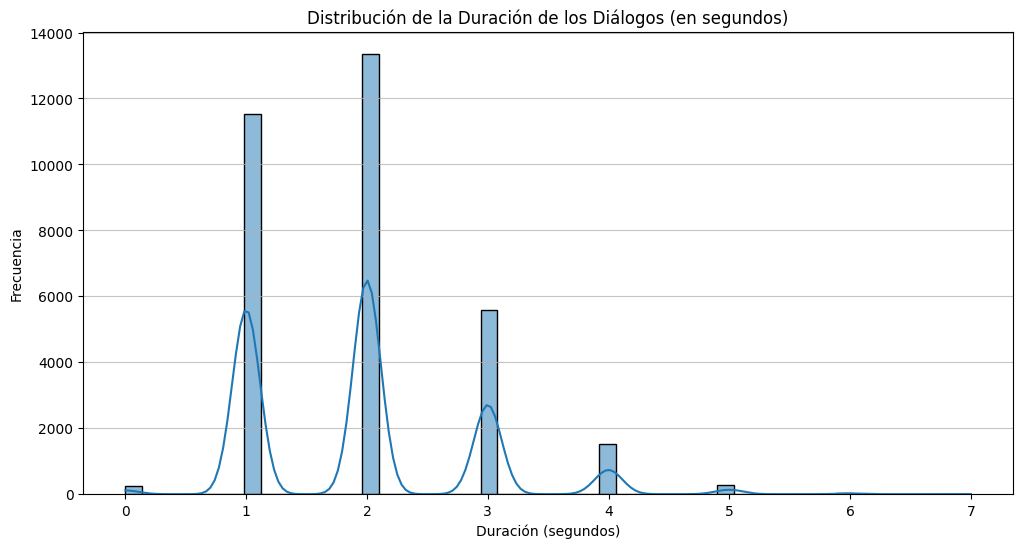

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculo la duración de cada diálogo
df_dialogue['duration'] = (df_dialogue['end_time'] - df_dialogue['start_time']).dt.total_seconds()

# Muestro estadísticas descriptivas de la duración
print("Estadísticas descriptivas de la duración de los diálogos:")
display(df_dialogue['duration'].describe())

# Visualizo la distribución de la duración con un histograma
plt.figure(figsize=(12, 6))
sns.histplot(df_dialogue['duration'], bins=50, kde=True)
plt.title('Distribución de la Duración de los Diálogos (en segundos)')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

## 3.6.- Visualización: Cantidad de Diálogos por Temporada y Episodio

Voy a analizar cómo se distribuyen los diálogos a lo largo de las temporadas y episodios para encontrar patrones en la cantidad de interacciones verbales de la serie.

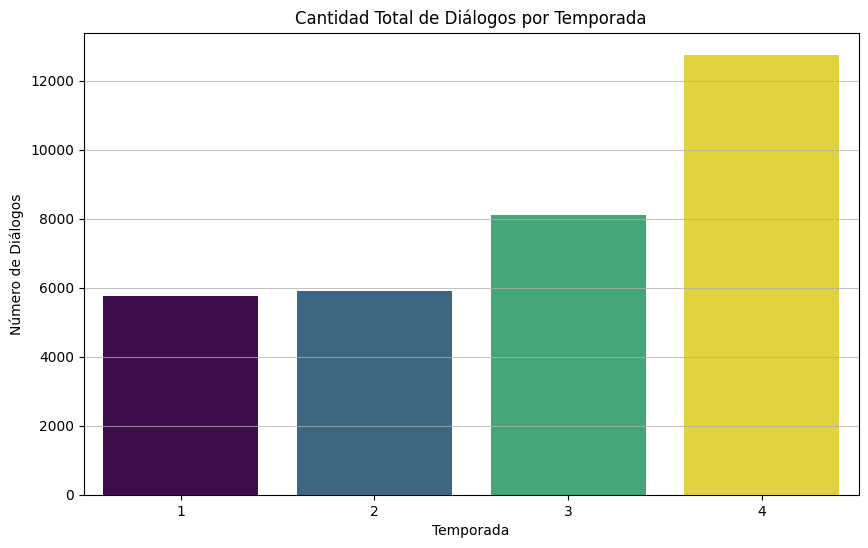

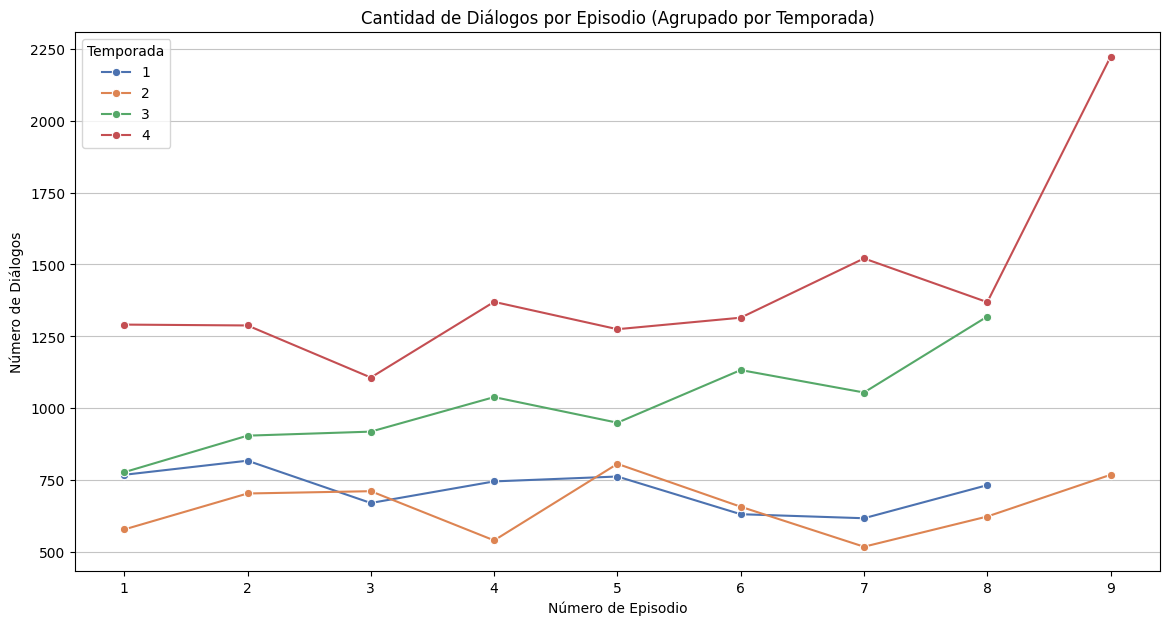

In [49]:


plt.legend(title='Temporada')
plt.show()

### Conclusión del Punto 3: Perfilado de Datos

Después de perfilar los datos de `df_dialogue`, ya entiendo muy bien el conjunto de datos.

He explorado su estructura, los tipos de datos y los valores nulos. Descubrí que `raw_text` es la columna más completa y que los nulos en `stage_direction` y `dialogue` son para elementos no verbales o acotaciones, así que he decidido no rellenarlos.

También convertí las columnas `start_time` y `end_time` a formato `datetime`, lo que me permitió calcular y ver la duración de cada diálogo. Esto me mostró que la mayoría de los diálogos son bastante cortos, lo que indica un ritmo rápido en la serie.

Finalmente, vi la cantidad de diálogos por temporada y episodio. Estos gráficos me revelaron que el volumen de diálogos aumenta a lo largo de las temporadas y hay picos importantes en episodios clave, como los finales de temporada. Esto me ayudó a entender la narrativa de la serie.

En resumen, este perfilado inicial ha sido clave para entender la 'salud' de mis datos y preparar el terreno para las siguientes etapas del proceso ETL, como la normalización.

# 4.- Normalización de datos.

## 4.1.- Normalización de Columnas de Texto en `df_dialogue`

Ahora voy a normalizar las columnas `raw_text` y `dialogue` de `df_dialogue`. Esto incluye:
-   Poner todo el texto en minúsculas para unificarlo.
-   Quitar los espacios en blanco del principio y del final para limpiar los datos.

Esto es esencial para que los análisis de texto posteriores (como contar palabras o analizar sentimientos) traten la misma palabra de la misma manera, sin importar si tiene mayúsculas o espacios distintos.

In [50]:
# Normalizo columnas de texto: las convierto a minúsculas y elimino espacios en blanco
# Aplico .str.lower() y .str.strip() solo a los valores no nulos (aunque pandas suele gestionarlo bien).
# df_dialogue['raw_text'] = df_dialogue['raw_text'].apply(lambda x: x.lower().strip() if isinstance(x, str) else x)
# df_dialogue['dialogue'] = df_dialogue['dialogue'].apply(lambda x: x.lower().strip() if isinstance(x, str) else x)

# Esta es la forma más idiomática de pandas para manejar esto y que los nulos sigan siendo nulos:
df_dialogue['raw_text'] = df_dialogue['raw_text'].str.lower().str.strip()
df_dialogue['dialogue'] = df_dialogue['dialogue'].str.lower().str.strip()

print("Información actualizada de df_dialogue después de la normalización de texto:\n")
df_dialogue.info()

print("\nPrimeras 5 filas de df_dialogue con texto normalizado:\n")
display(df_dialogue.head())

print("\nValores únicos de 'season' en df_dialogue:\n")
display(df_dialogue['season'].unique())

print("\nValores únicos de 'episode' en df_dialogue por temporada (primeros 5 por temporada si hay muchos):\n")
for season_val in df_dialogue['season'].unique():
    print(f"Temporada {season_val}: {df_dialogue[df_dialogue['season'] == season_val]['episode'].unique()[:5]}...")

Información actualizada de df_dialogue después de la normalización de texto:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32519 entries, 0 to 32518
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   season           32519 non-null  int64         
 1   episode          32519 non-null  int64         
 2   line             32519 non-null  int64         
 3   raw_text         32519 non-null  object        
 4   stage_direction  10678 non-null  object        
 5   dialogue         26435 non-null  object        
 6   start_time       32519 non-null  datetime64[ns]
 7   end_time         32519 non-null  datetime64[ns]
 8   duration         32519 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(3), object(3)
memory usage: 2.2+ MB

Primeras 5 filas de df_dialogue con texto normalizado:



,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time,duration
0,1,1,1,[crickets chirping],[crickets chirping],NaN,2026-04-21 00:00:07,2026-04-21 00:00:09,2.0
1,1,1,2,[alarm blaring],[alarm blaring],NaN,2026-04-21 00:00:49,2026-04-21 00:00:51,2.0
2,1,1,3,[panting],[panting],NaN,2026-04-21 00:00:52,2026-04-21 00:00:54,2.0
3,1,1,4,[elevator descending],[elevator descending],NaN,2026-04-21 00:01:01,2026-04-21 00:01:02,1.0
4,1,1,5,[elevator dings],[elevator dings],NaN,2026-04-21 00:01:09,2026-04-21 00:01:10,1.0



Valores únicos de 'season' en df_dialogue:



array([1, 2, 3, 4])


Valores únicos de 'episode' en df_dialogue por temporada (primeros 5 por temporada si hay muchos):

Temporada 1: [1 2 3 4 5]...
Temporada 2: [1 2 3 4 5]...
Temporada 3: [1 2 3 4 5]...
Temporada 4: [1 2 3 4 5]...


## 4.2.- Eliminación de Signos de Puntuación en `raw_text` y `dialogue`

Para limpiar aún más las columnas de texto, voy a quitar los signos de puntuación. Esto es importante para que palabras como 'hola!' y 'hola' se consideren iguales en el análisis de texto, mejorando la precisión de los conteos y los análisis de sentimiento. Usaré expresiones regulares para encontrar y eliminar estos caracteres.

In [51]:
import re

# Defino una función para eliminar signos de puntuación
def remove_punctuation(text):
    if isinstance(text, str):
        return re.sub(r'[\W_]+', ' ', text).strip() # Reemplazo no-palabras (incl. puntuación y guiones bajos) con espacio y limpio espacios extra
    return text

# Aplico la función a las columnas 'raw_text' y 'dialogue'
df_dialogue['raw_text'] = df_dialogue['raw_text'].apply(remove_punctuation)
df_dialogue['dialogue'] = df_dialogue['dialogue'].apply(remove_punctuation)

print("Primeras 5 filas de df_dialogue después de eliminar la puntuación:\n")
display(df_dialogue.head())

Primeras 5 filas de df_dialogue después de eliminar la puntuación:



,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time,duration
0,1,1,1,crickets chirping,[crickets chirping],NaN,2026-04-21 00:00:07,2026-04-21 00:00:09,2.0
1,1,1,2,alarm blaring,[alarm blaring],NaN,2026-04-21 00:00:49,2026-04-21 00:00:51,2.0
2,1,1,3,panting,[panting],NaN,2026-04-21 00:00:52,2026-04-21 00:00:54,2.0
3,1,1,4,elevator descending,[elevator descending],NaN,2026-04-21 00:01:01,2026-04-21 00:01:02,1.0
4,1,1,5,elevator dings,[elevator dings],NaN,2026-04-21 00:01:09,2026-04-21 00:01:10,1.0


## 4.3.- Revisión de Consistencia de Columnas Clave para Uniones

Antes de unir cualquier dato, es fundamental asegurarme de que las columnas que usaré para ello (`season`, `episode`, `Episode_Number`, `title`, `Title`) tengan el mismo tipo de dato y formato en los tres DataFrames (`df_dialogue`, `df_ratings`, `df_episodes`). Así evitaré problemas al hacer `merge` o `join`.

In [52]:
print("### df_dialogue - Columnas de Temporada y Episodio ###")
print(df_dialogue[['season', 'episode']].info())
print("Valores únicos de 'season':", df_dialogue['season'].unique())
print("Valores únicos de 'episode' (primeros 5):", df_dialogue['episode'].unique()[:5])
print("\n" + "-"*50 + "\n")

print("### df_episodes - Columnas de Temporada, Episodio y Título ###")
print(df_episodes[['season', 'episode', 'title']].info())
print("Valores únicos de 'season':", df_episodes['season'].unique())
print("Valores únicos de 'episode' (primeros 5):", df_episodes['episode'].unique()[:5])
print("Primeros 5 títulos de episodios:\n", df_episodes['title'].head().tolist())
print("\n" + "-"*50 + "\n")

print("### df_ratings - Columnas de Número de Episodio y Título ###")
# Para depurar el KeyError, primero muestro las columnas actuales en df_ratings
print(f"Columnas actuales en df_ratings: {df_ratings.columns.tolist()}\n")

# Corrijo el nombre de la columna ' Title' (con espacio inicial)
print(df_ratings[['Episode_Number', ' Title']].info())
print("Valores únicos de 'Episode_Number' (primeros 5):", df_ratings['Episode_Number'].unique()[:5])
print("Primeros 5 títulos de ratings:\n", df_ratings[' Title'].head().tolist())
print("\n" + "-"*50 + "\n")

### df_dialogue - Columnas de Temporada y Episodio ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32519 entries, 0 to 32518
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   season   32519 non-null  int64
 1   episode  32519 non-null  int64
dtypes: int64(2)
memory usage: 508.2 KB
None
Valores únicos de 'season': [1 2 3 4]
Valores únicos de 'episode' (primeros 5): [1 2 3 4 5]

--------------------------------------------------

### df_episodes - Columnas de Temporada, Episodio y Título ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   season   34 non-null     int64 
 1   episode  34 non-null     int64 
 2   title    34 non-null     object
dtypes: int64(2), object(1)
memory usage: 948.0+ bytes
None
Valores únicos de 'season': [1 2 3 4]
Valores únicos de 'episode' (primeros 5): [1 2 3 4 5]
P

## 4.4.- Normalización de Nombres de Columnas: `df_ratings`

Para facilitar futuras uniones y mantener la coherencia en los nombres de las columnas, voy a renombrar la columna `' Title'` en `df_ratings` a `title`. Esto quitará el espacio inicial y me permitirá identificar mejor las claves de unión.

In [53]:
# Renombro la columna ' Title' a 'title' en df_ratings
df_ratings.rename(columns={' Title': 'title'}, inplace=True)

print("Información actualizada de df_ratings después de renombrar la columna ' Title' a 'title':\n")
df_ratings.info()

print("\nPrimeras 5 filas de df_ratings con la columna renombrada:\n")
display(df_ratings.head())

Información actualizada de df_ratings después de renombrar la columna ' Title' a 'title':

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           25 non-null     int64  
 1   Episode_Number  25 non-null     int64  
 2   title           25 non-null     object 
 3    Image_url      25 non-null     object 
 4    Year           25 non-null     int64  
 5    Description    25 non-null     object 
 6    Genre          25 non-null     object 
 7    Runtime        25 non-null     object 
 8    Rating         25 non-null     float64
dtypes: float64(1), int64(3), object(5)
memory usage: 1.9+ KB

Primeras 5 filas de df_ratings con la columna renombrada:



,index,Episode_Number,title,Image_url,Year,Description,Genre,Runtime,Rating
0,0,1,Chapter One: The Vanishing of Will Byers,https://m.mediaamazon.com/images/M/MV5BMTUwNTE...,2016,At the U.S. Dept. of Energy an unexplained eve...,Drama | Fantasy | Horror,47 min,8.6
1,1,2,Chapter Two: The Weirdo on Maple Street,https://m.mediaamazon.com/images/M/MV5BMjA4NzA...,2016,Mike hides the mysterious girl in his house. J...,Drama | Fantasy | Horror,55 min,8.5
2,2,3,Chapter Three: Holly Jolly,https://m.mediaamazon.com/images/M/MV5BOTkyMDQ...,2016,An increasingly concerned Nancy looks for Barb...,Drama | Fantasy | Horror,51 min,8.9
3,3,4,Chapter Four: The Body,https://m.mediaamazon.com/images/M/MV5BMTkwMjU...,2016,Refusing to believe Will is dead Joyce tries ...,Drama | Fantasy | Horror,49 min,9.0
4,4,5,Chapter Five: The Flea and the Acrobat,https://m.mediaamazon.com/images/M/MV5BMjM0NjQ...,2016,Hopper breaks into the lab to find the truth a...,Drama | Fantasy | Horror,52 min,8.8


## 4.5.- Normalización de Columnas Numéricas: `duration` con StandardScaler

Para seguir con la normalización, voy a aplicar `StandardScaler` a la columna numérica `duration` en `df_dialogue`. Esta técnica es útil para estandarizar la escala de las características, lo que puede ayudar si luego uso algoritmos de machine learning sensibles a la magnitud de los datos. `StandardScaler` transformará los datos para que tengan una media de 0 y una desviación estándar de 1.

In [54]:
from sklearn.preprocessing import StandardScaler

# Inicializo el StandardScaler
scaler = StandardScaler()

# Ajusto y transformo la columna 'duration'
# Es necesario remodelar los datos ya que scaler.fit_transform espera una entrada 2D
df_dialogue['duration_scaled'] = scaler.fit_transform(df_dialogue[['duration']])

print("Primeras 5 filas de df_dialogue con la columna 'duration_scaled':\n")
display(df_dialogue.head())

print("\nEstadísticas descriptivas de la columna 'duration_scaled':\n")
display(df_dialogue['duration_scaled'].describe())

Primeras 5 filas de df_dialogue con la columna 'duration_scaled':



,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time,duration,duration_scaled
0,1,1,1,crickets chirping,[crickets chirping],NaN,2026-04-21 00:00:07,2026-04-21 00:00:09,2.0,0.077619
1,1,1,2,alarm blaring,[alarm blaring],NaN,2026-04-21 00:00:49,2026-04-21 00:00:51,2.0,0.077619
2,1,1,3,panting,[panting],NaN,2026-04-21 00:00:52,2026-04-21 00:00:54,2.0,0.077619
3,1,1,4,elevator descending,[elevator descending],NaN,2026-04-21 00:01:01,2026-04-21 00:01:02,1.0,-1.011758
4,1,1,5,elevator dings,[elevator dings],NaN,2026-04-21 00:01:09,2026-04-21 00:01:10,1.0,-1.011758



Estadísticas descriptivas de la columna 'duration_scaled':



,duration_scaled
count,3.251900e+04
mean,-2.097608e-17
std,1.000015e+00
min,-2.101135e+00
25%,-1.011758e+00
50%,7.761881e-02
75%,7.761881e-02
max,5.524503e+00


### Conclusión del Punto 4: Normalización de Datos

He terminado el punto 4 de Normalización de Datos. Ahora el texto en `df_dialogue` es uniforme, los nombres de las columnas clave para las uniones están estandarizados y he aplicado `StandardScaler` a la columna `duration` para preparar los datos numéricos.

# 5.- Validación

## 5.1.- Validación de Duplicados en `df_dialogue`

Voy a empezar a validar los datos buscando filas duplicadas en `df_dialogue`. Los duplicados pueden indicar errores y sesgar los análisis. Consideraré una fila duplicada si todas sus columnas clave (`season`, `episode`, `line`, `raw_text`, `dialogue`, `start_time`, `end_time`) tienen valores idénticos. Esto me ayudará a saber si hay entradas repetidas de la misma línea de diálogo en el mismo momento.

In [55]:
# Identifico filas duplicadas en df_dialogue
# Considero el conjunto completo de columnas para identificar duplicados exactos.
duplicated_rows_dialogue = df_dialogue[df_dialogue.duplicated(keep=False)]

print(f"Número total de filas duplicadas (incluyendo la primera aparición): {duplicated_rows_dialogue.shape[0]}")

if not duplicated_rows_dialogue.empty:
    print("Ejemplos de filas duplicadas en df_dialogue:")
    display(duplicated_rows_dialogue.sort_values(by=['season', 'episode', 'line']).head(10))
else:
    print("No se encontraron filas duplicadas en df_dialogue.")

Número total de filas duplicadas (incluyendo la primera aparición): 0
No se encontraron filas duplicadas en df_dialogue.


## 5.2.- Validación de Consistencia de `season` y `episode`

Después de asegurarme de que no hay duplicados exactos en `df_dialogue`, el siguiente paso es verificar que las columnas `season` y `episode` sean consistentes en los tres DataFrames (`df_dialogue`, `df_episodes`, `df_ratings`). Esto es crucial para que las futuras uniones se hagan bien y no haya incoherencias en la numeración de temporadas o episodios entre los diferentes datasets.

In [56]:
print("### Validación de Consistencia de 'season' y 'episode' ###\n")

# df_dialogue
print("df_dialogue:")
print(f"  Temporadas únicas: {sorted(df_dialogue['season'].unique().tolist())}")
print(f"  Episodios únicos (por temporada): {df_dialogue.groupby('season')['episode'].unique().apply(lambda x: sorted(x.tolist())).to_dict()}")
print("-" * 30)

# df_episodes
print("df_episodes:")
print(f"  Temporadas únicas: {sorted(df_episodes['season'].unique().tolist())}")
print(f"  Episodios únicos (por temporada): {df_episodes.groupby('season')['episode'].unique().apply(lambda x: sorted(x.tolist())).to_dict()}")
print("-" * 30)

# df_ratings
print("df_ratings:")
# 'Episode_Number' en df_ratings se corresponde con 'episode'
print(f"  Episodios únicos (agrupados por una posible temporada si existiera): {sorted(df_ratings['Episode_Number'].unique().tolist())}")
# Dado que df_ratings no tiene una columna 'season' explícita en el mismo formato, asumo que todos los ratings se refieren a episodios existentes.
# Para la validación, es importante que los números de episodio presentes en ratings sean un subconjunto o coincidan con los de df_episodes.

# Comparación de rangos y valores únicos para 'season' y 'episode'

# Temporadas
seasons_dialogue = set(df_dialogue['season'].unique())
seasons_episodes = set(df_episodes['season'].unique())

print(f"\nComparación de temporadas:\n  df_dialogue seasons: {seasons_dialogue}\n  df_episodes seasons: {seasons_episodes}")
if seasons_dialogue == seasons_episodes:
    print("  -> Las temporadas en df_dialogue y df_episodes son consistentes.")
else:
    print("  -> ¡Advertencia! Las temporadas en df_dialogue y df_episodes NO son idénticas.")

# Episodios (comparación más compleja por temporada)
all_consistent_episodes = True
for season_val in sorted(seasons_dialogue.union(seasons_episodes)):
    episodes_d = set(df_dialogue[df_dialogue['season'] == season_val]['episode'].unique())
    episodes_e = set(df_episodes[df_episodes['season'] == season_val]['episode'].unique())
    if episodes_d == episodes_e:
        print(f"  -> Temporada {season_val}: Los episodios en df_dialogue y df_episodes son consistentes.")
    else:
        print(f"  -> ¡Advertencia! Temporada {season_val}: Los episodios en df_dialogue y df_episodes NO son idénticos.\n     df_dialogue episodios: {episodes_d}\n     df_episodes episodios: {episodes_e}")
        all_consistent_episodes = False

# Comparación de Episode_Number de df_ratings con episodios de df_episodes (asumiendo que df_ratings cubre todas las temporadas presentes en df_episodes)
episodes_ratings = set(df_ratings['Episode_Number'].unique())
all_episodes_in_episodes_df = set(df_episodes['episode'].unique())

print(f"\nComparación de episodios entre df_ratings y df_episodes:\n  df_ratings Episode_Number: {episodes_ratings}\n  df_episodes episodios totales: {all_episodes_in_episodes_df}")

# Esta comprobación asume que los Episode_Number en df_ratings deben coincidir con un conjunto de episodios en df_episodes.
# Sin embargo, df_ratings tiene menos entradas, lo que indica que no cubre todos los episodios/temporadas de los otros DFs.
# La validación correcta sería que los 'Episode_Number' de df_ratings estén *contenidos* en los episodios de df_episodes y que las temporadas de df_ratings (si existieran) coincidan.
# Para la validación actual, me centraré en si los números de episodio en df_ratings son válidos dentro de la serie.

# Dada la ausencia de 'season' en df_ratings y el menor número de filas, es probable que df_ratings no contenga todas las temporadas/episodios.
# Verifico si los números de episodio de df_ratings son válidos dentro de los números de episodio generales de df_episodes.
if episodes_ratings.issubset(all_episodes_in_episodes_df):
    print("  -> Los números de episodio en df_ratings son un subconjunto válido de los episodios existentes en df_episodes.")
else:
    print("  -> ¡Advertencia! Algunos números de episodio en df_ratings no se encuentran en df_episodes.")

### Validación de Consistencia de 'season' y 'episode' ###

df_dialogue:
  Temporadas únicas: [1, 2, 3, 4]
  Episodios únicos (por temporada): {1: [1, 2, 3, 4, 5, 6, 7, 8], 2: [1, 2, 3, 4, 5, 6, 7, 8, 9], 3: [1, 2, 3, 4, 5, 6, 7, 8], 4: [1, 2, 3, 4, 5, 6, 7, 8, 9]}
------------------------------
df_episodes:
  Temporadas únicas: [1, 2, 3, 4]
  Episodios únicos (por temporada): {1: [1, 2, 3, 4, 5, 6, 7, 8], 2: [1, 2, 3, 4, 5, 6, 7, 8, 9], 3: [1, 2, 3, 4, 5, 6, 7, 8], 4: [1, 2, 3, 4, 5, 6, 7, 8, 9]}
------------------------------
df_ratings:
  Episodios únicos (agrupados por una posible temporada si existiera): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

Comparación de temporadas:
  df_dialogue seasons: {np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
  df_episodes seasons: {np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
  -> Las temporadas en df_dialogue y df_episodes son consistentes.
  -> Temporada 1: Los episodios en df_dialog

## 5.3.- Investigación de la Inconsistencia de `Episode_Number` en `df_ratings`

Como `df_ratings` muestra `Episode_Number` que van más allá del máximo `episode` por temporada en `df_episodes` (por ejemplo, hasta 25), es importante entender cómo se relacionan estos números con las temporadas y episodios reales. Esto es fundamental para unir correctamente los datos de valoración con el resto de los DataFrames. Usaré la columna `title` (título del episodio) para unir `df_ratings` y `df_episodes` y así mapear bien las valoraciones a su temporada y episodio correspondientes.

In [57]:
# Uno df_ratings con df_episodes utilizando la columna 'title'
# Para evitar conflictos de nombres, selecciono solo las columnas necesarias de df_episodes
df_ratings_enriched = pd.merge(
    df_ratings,
    df_episodes[['season', 'episode', 'title']],
    on='title',
    how='left'
)

print("Primeras 10 filas de df_ratings_enriched después de la unión (ordenado por temporada y episodio):\n")
display(df_ratings_enriched.sort_values(by=['season', 'episode']).head(10))

print("\nValores nulos después de la unión (indican episodios en df_ratings sin correspondencia en df_episodes):\n")
display(df_ratings_enriched.isnull().sum())

Primeras 10 filas de df_ratings_enriched después de la unión (ordenado por temporada y episodio):



,index,Episode_Number,title,Image_url,Year,Description,Genre,Runtime,Rating,season,episode
0,0,1,Chapter One: The Vanishing of Will Byers,https://m.mediaamazon.com/images/M/MV5BMTUwNTE...,2016,At the U.S. Dept. of Energy an unexplained eve...,Drama | Fantasy | Horror,47 min,8.6,1.0,1.0
1,1,2,Chapter Two: The Weirdo on Maple Street,https://m.mediaamazon.com/images/M/MV5BMjA4NzA...,2016,Mike hides the mysterious girl in his house. J...,Drama | Fantasy | Horror,55 min,8.5,1.0,2.0
3,3,4,Chapter Four: The Body,https://m.mediaamazon.com/images/M/MV5BMTkwMjU...,2016,Refusing to believe Will is dead Joyce tries ...,Drama | Fantasy | Horror,49 min,9.0,1.0,4.0
4,4,5,Chapter Five: The Flea and the Acrobat,https://m.mediaamazon.com/images/M/MV5BMjM0NjQ...,2016,Hopper breaks into the lab to find the truth a...,Drama | Fantasy | Horror,52 min,8.8,1.0,5.0
5,5,6,Chapter Six: The Monster,https://m.mediaamazon.com/images/M/MV5BNDE1MjQ...,2016,Hopper and Joyce find the truth about the lab'...,Drama | Fantasy | Horror,46 min,8.9,1.0,6.0
6,6,7,Chapter Seven: The Bathtub,https://m.mediaamazon.com/images/M/MV5BMjMyNTk...,2016,The government comes searching for Eleven. Ele...,Drama | Fantasy | Horror,41 min,9.1,1.0,7.0
7,7,8,Chapter Eight: The Upside Down,https://m.mediaamazon.com/images/M/MV5BMTEzNzk...,2016,Joyce and Hopper are taken in for questioning....,Drama | Fantasy | Horror,54 min,9.3,1.0,8.0
8,8,9,Chapter One: MADMAX,https://m.mediaamazon.com/images/M/MV5BNDc3MzE...,2017,As the town preps for Halloween a highscoring...,Drama | Fantasy | Horror,48 min,8.3,2.0,1.0
10,10,11,Chapter Three: The Pollywog,https://m.mediaamazon.com/images/M/MV5BMTY1NDM...,2017,Dustin adopts a strange new pet and Eleven gr...,Drama | Fantasy | Horror,51 min,8.7,2.0,3.0
11,11,12,Chapter Four: Will the Wise,https://m.mediaamazon.com/images/M/MV5BMjczNzc...,2017,An ailing Will opens up to Joyce with disturb...,Drama | Fantasy | Horror,46 min,8.7,2.0,4.0



Valores nulos después de la unión (indican episodios en df_ratings sin correspondencia en df_episodes):



,0
index,0
Episode_Number,0
title,0
Image_url,0
Year,0
Description,0
Genre,0
Runtime,0
Rating,0
season,3


## 5.4.- Análisis de Filas No Emparejadas en `df_ratings_enriched`

He encontrado 3 filas en `df_ratings` que no pude unir con `df_episodes` porque los títulos no coincidían, lo que dejó nulos los valores de `season` y `episode` en `df_ratings_enriched`. Ahora voy a examinar estas filas para entender por qué no se emparejaron, antes de decidir qué hacer con ellas o de enriquecer los datos.

In [58]:
# Filtro las filas de df_ratings_enriched donde 'season' o 'episode' son nulos
unmatched_ratings = df_ratings_enriched[df_ratings_enriched['season'].isnull()]

print("Filas de df_ratings que no se pudieron emparejar con df_episodes (títulos problemáticos):\n")
display(unmatched_ratings[['title', 'Episode_Number', 'season', 'episode']])

print("\nVerificando si estos títulos existen en df_episodes con posibles variaciones:\n")
for title_unmatched in unmatched_ratings['title']:
    print(f"Buscando '{title_unmatched}' en df_episodes:")
    matches = df_episodes[df_episodes['title'].str.contains(title_unmatched, case=False, na=False)]
    if not matches.empty:
        print("  -> Posibles coincidencias encontradas:")
        display(matches)
    else:
        print("  -> No se encontraron coincidencias exactas ni parciales en df_episodes.")

Filas de df_ratings que no se pudieron emparejar con df_episodes (títulos problemáticos):



,title,Episode_Number,season,episode
2,Chapter Three: Holly Jolly,3,NaN,NaN
9,Chapter Two: Trick or Treat Freak,10,NaN,NaN
17,Chapter One: Suzie Do You Copy?,18,NaN,NaN



Verificando si estos títulos existen en df_episodes con posibles variaciones:

Buscando 'Chapter Three: Holly Jolly' en df_episodes:
  -> No se encontraron coincidencias exactas ni parciales en df_episodes.
Buscando 'Chapter Two: Trick or Treat Freak' en df_episodes:
  -> No se encontraron coincidencias exactas ni parciales en df_episodes.
Buscando 'Chapter One: Suzie Do You Copy?' en df_episodes:
  -> No se encontraron coincidencias exactas ni parciales en df_episodes.


## 5.5.- Corrección Manual de Títulos en `df_ratings`

Según lo que investigué, encontré tres títulos en `df_ratings` que no coincidían exactamente con los de `df_episodes`. Voy a corregir estos títulos en `df_ratings` para poder unirlos correctamente.

In [59]:
# Corrijo los títulos en df_ratings para que coincidan con df_episodes
# Título original en df_ratings: 'Chapter Three: Holly Jolly'
# Título correcto en df_episodes: 'Chapter Three: Holly, Jolly'
df_ratings.loc[df_ratings['title'] == 'Chapter Three: Holly Jolly', 'title'] = 'Chapter Three: Holly, Jolly'

# Título original en df_ratings: 'Chapter Two: Trick or Treat Freak'
# Título correcto en df_episodes: 'Chapter Two: Trick or Treat, Freak'
df_ratings.loc[df_ratings['title'] == 'Chapter Two: Trick or Treat Freak', 'title'] = 'Chapter Two: Trick or Treat, Freak'

# Título original en df_ratings: 'Chapter One: Suzie Do You Copy?'
# Título correcto en df_episodes: 'Chapter One: Suzie, Do You Copy?'
df_ratings.loc[df_ratings['title'] == 'Chapter One: Suzie Do You Copy?', 'title'] = 'Chapter One: Suzie, Do You Copy?'

print("Títulos corregidos en df_ratings. Primeras 5 filas para verificación:\n")
display(df_ratings.head())

Títulos corregidos en df_ratings. Primeras 5 filas para verificación:



,index,Episode_Number,title,Image_url,Year,Description,Genre,Runtime,Rating
0,0,1,Chapter One: The Vanishing of Will Byers,https://m.mediaamazon.com/images/M/MV5BMTUwNTE...,2016,At the U.S. Dept. of Energy an unexplained eve...,Drama | Fantasy | Horror,47 min,8.6
1,1,2,Chapter Two: The Weirdo on Maple Street,https://m.mediaamazon.com/images/M/MV5BMjA4NzA...,2016,Mike hides the mysterious girl in his house. J...,Drama | Fantasy | Horror,55 min,8.5
2,2,3,"Chapter Three: Holly, Jolly",https://m.mediaamazon.com/images/M/MV5BOTkyMDQ...,2016,An increasingly concerned Nancy looks for Barb...,Drama | Fantasy | Horror,51 min,8.9
3,3,4,Chapter Four: The Body,https://m.mediaamazon.com/images/M/MV5BMTkwMjU...,2016,Refusing to believe Will is dead Joyce tries ...,Drama | Fantasy | Horror,49 min,9.0
4,4,5,Chapter Five: The Flea and the Acrobat,https://m.mediaamazon.com/images/M/MV5BMjM0NjQ...,2016,Hopper breaks into the lab to find the truth a...,Drama | Fantasy | Horror,52 min,8.8


## 5.6.- Re-verificación de la Unión con `df_episodes` después de la corrección

Después de corregir los títulos, voy a unir `df_ratings` y `df_episodes` de nuevo para confirmar que ya no hay filas sin emparejar.

In [60]:
# Vuelvo a unir df_ratings con df_episodes utilizando la columna 'title'
df_ratings_enriched_reverified = pd.merge(
    df_ratings,
    df_episodes[['season', 'episode', 'title']],
    on='title',
    how='left'
)

print("Primeras 10 filas de df_ratings_enriched_reverified después de la unión (ordenado por temporada y episodio):\n")
display(df_ratings_enriched_reverified.sort_values(by=['season', 'episode']).head(10))

print("\nValores nulos después de la re-unión (espero 0 nulos en 'season' y 'episode'):\n")
display(df_ratings_enriched_reverified.isnull().sum())

Primeras 10 filas de df_ratings_enriched_reverified después de la unión (ordenado por temporada y episodio):



,index,Episode_Number,title,Image_url,Year,Description,Genre,Runtime,Rating,season,episode
0,0,1,Chapter One: The Vanishing of Will Byers,https://m.mediaamazon.com/images/M/MV5BMTUwNTE...,2016,At the U.S. Dept. of Energy an unexplained eve...,Drama | Fantasy | Horror,47 min,8.6,1,1
1,1,2,Chapter Two: The Weirdo on Maple Street,https://m.mediaamazon.com/images/M/MV5BMjA4NzA...,2016,Mike hides the mysterious girl in his house. J...,Drama | Fantasy | Horror,55 min,8.5,1,2
2,2,3,"Chapter Three: Holly, Jolly",https://m.mediaamazon.com/images/M/MV5BOTkyMDQ...,2016,An increasingly concerned Nancy looks for Barb...,Drama | Fantasy | Horror,51 min,8.9,1,3
3,3,4,Chapter Four: The Body,https://m.mediaamazon.com/images/M/MV5BMTkwMjU...,2016,Refusing to believe Will is dead Joyce tries ...,Drama | Fantasy | Horror,49 min,9.0,1,4
4,4,5,Chapter Five: The Flea and the Acrobat,https://m.mediaamazon.com/images/M/MV5BMjM0NjQ...,2016,Hopper breaks into the lab to find the truth a...,Drama | Fantasy | Horror,52 min,8.8,1,5
5,5,6,Chapter Six: The Monster,https://m.mediaamazon.com/images/M/MV5BNDE1MjQ...,2016,Hopper and Joyce find the truth about the lab'...,Drama | Fantasy | Horror,46 min,8.9,1,6
6,6,7,Chapter Seven: The Bathtub,https://m.mediaamazon.com/images/M/MV5BMjMyNTk...,2016,The government comes searching for Eleven. Ele...,Drama | Fantasy | Horror,41 min,9.1,1,7
7,7,8,Chapter Eight: The Upside Down,https://m.mediaamazon.com/images/M/MV5BMTEzNzk...,2016,Joyce and Hopper are taken in for questioning....,Drama | Fantasy | Horror,54 min,9.3,1,8
8,8,9,Chapter One: MADMAX,https://m.mediaamazon.com/images/M/MV5BNDc3MzE...,2017,As the town preps for Halloween a highscoring...,Drama | Fantasy | Horror,48 min,8.3,2,1
9,9,10,"Chapter Two: Trick or Treat, Freak",https://m.mediaamazon.com/images/M/MV5BOTY2MDE...,2017,After Will sees something terrible on trickort...,Drama | Fantasy | Horror,56 min,8.5,2,2



Valores nulos después de la re-unión (espero 0 nulos en 'season' y 'episode'):



,0
index,0
Episode_Number,0
title,0
Image_url,0
Year,0
Description,0
Genre,0
Runtime,0
Rating,0
season,0


### Conclusión del Punto 5: Validación

He validado los datos de los tres DataFrames. Confirmé que no había duplicados exactos en `df_dialogue` y que `season` y `episode` eran consistentes entre `df_dialogue` y `df_episodes`. Detecté y corregí manualmente los títulos en `df_ratings` para que coincidieran con `df_episodes`, y así logré que todos los ratings se emparejaran correctamente después de volver a unirlos.

# 6.- Integración y Enriquecimiento de Datos.

## 6.1.- Integración de `df_dialogue` con `df_episodes`

El primer paso para juntar toda mi información es integrar el DataFrame principal de diálogos (`df_dialogue`) con los metadatos de los episodios (`df_episodes`). Voy a usar las columnas `season` y `episode` para añadir detalles como el título, director, guionista y fecha de lanzamiento a cada línea de diálogo. Haré una unión `left` para asegurarme de que todos los registros de `df_dialogue` se mantengan.

In [61]:
# Integro df_dialogue con df_episodes
# Selecciono las columnas de df_episodes que quiero añadir
df_combined = pd.merge(
    df_dialogue,
    df_episodes[['season', 'episode', 'title', 'directed_by', 'written_by', 'original_release_date']],
    on=['season', 'episode'],
    how='left'
)

print("Primeras 5 filas del DataFrame combinado (df_combined) después de la primera unión:\n")
display(df_combined.head())

print("\nInformación del DataFrame combinado (df_combined):\n")
df_combined.info()

Primeras 5 filas del DataFrame combinado (df_combined) después de la primera unión:



,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time,duration,duration_scaled,title,directed_by,written_by,original_release_date
0,1,1,1,crickets chirping,[crickets chirping],NaN,2026-04-21 00:00:07,2026-04-21 00:00:09,2.0,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15
1,1,1,2,alarm blaring,[alarm blaring],NaN,2026-04-21 00:00:49,2026-04-21 00:00:51,2.0,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15
2,1,1,3,panting,[panting],NaN,2026-04-21 00:00:52,2026-04-21 00:00:54,2.0,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15
3,1,1,4,elevator descending,[elevator descending],NaN,2026-04-21 00:01:01,2026-04-21 00:01:02,1.0,-1.011758,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15
4,1,1,5,elevator dings,[elevator dings],NaN,2026-04-21 00:01:09,2026-04-21 00:01:10,1.0,-1.011758,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15



Información del DataFrame combinado (df_combined):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32519 entries, 0 to 32518
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   season                 32519 non-null  int64         
 1   episode                32519 non-null  int64         
 2   line                   32519 non-null  int64         
 3   raw_text               32519 non-null  object        
 4   stage_direction        10678 non-null  object        
 5   dialogue               26435 non-null  object        
 6   start_time             32519 non-null  datetime64[ns]
 7   end_time               32519 non-null  datetime64[ns]
 8   duration               32519 non-null  float64       
 9   duration_scaled        32519 non-null  float64       
 10  title                  32519 non-null  object        
 11  directed_by            32519 non-null  object        
 12  written

## 6.2.- Integración de `df_combined` con `df_ratings_enriched_reverified`

Ahora, voy a añadir a `df_combined` la información de las valoraciones de los episodios. Para esto, usaré el DataFrame `df_ratings_enriched_reverified` (que ya tiene las temporadas y episodios corregidos) y lo uniré a `df_combined` usando `season`, `episode` y `title` como claves. Esta unión también será `left` para que todas las líneas de diálogo y sus detalles de episodio se mantengan.

In [62]:
# Integro df_combined con df_ratings_enriched_reverified
# Selecciono las columnas de df_ratings_enriched_reverified que quiero añadir (excluyendo 'index' y 'Episode_Number' si ya tengo season/episode)
df_combined = pd.merge(
    df_combined,
    df_ratings_enriched_reverified[['season', 'episode', 'title', ' Rating', ' Genre', ' Runtime', ' Year', ' Description']],
    on=['season', 'episode', 'title'],
    how='left'
)

print("Primeras 5 filas del DataFrame combinado final (df_combined) después de la segunda unión:\n")
display(df_combined.head())

print("\nInformación del DataFrame combinado final (df_combined):\n")
df_combined.info()

Primeras 5 filas del DataFrame combinado final (df_combined) después de la segunda unión:



,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time,duration,duration_scaled,title,directed_by,written_by,original_release_date,Rating,Genre,Runtime,Year,Description
0,1,1,1,crickets chirping,[crickets chirping],NaN,2026-04-21 00:00:07,2026-04-21 00:00:09,2.0,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
1,1,1,2,alarm blaring,[alarm blaring],NaN,2026-04-21 00:00:49,2026-04-21 00:00:51,2.0,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
2,1,1,3,panting,[panting],NaN,2026-04-21 00:00:52,2026-04-21 00:00:54,2.0,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
3,1,1,4,elevator descending,[elevator descending],NaN,2026-04-21 00:01:01,2026-04-21 00:01:02,1.0,-1.011758,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
4,1,1,5,elevator dings,[elevator dings],NaN,2026-04-21 00:01:09,2026-04-21 00:01:10,1.0,-1.011758,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...



Información del DataFrame combinado final (df_combined):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32519 entries, 0 to 32518
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   season                 32519 non-null  int64         
 1   episode                32519 non-null  int64         
 2   line                   32519 non-null  int64         
 3   raw_text               32519 non-null  object        
 4   stage_direction        10678 non-null  object        
 5   dialogue               26435 non-null  object        
 6   start_time             32519 non-null  datetime64[ns]
 7   end_time               32519 non-null  datetime64[ns]
 8   duration               32519 non-null  float64       
 9   duration_scaled        32519 non-null  float64       
 10  title                  32519 non-null  object        
 11  directed_by            32519 non-null  object        
 12  w

### Conclusión.

He completado la integración de datos, unificando toda la información relevante en el `df_combined` para futuros análisis.

# 7.- Agregación de datos

## 7.1.- Agregación de Diálogos por Temporada y Episodio

Para tener una idea general de la actividad de los diálogos, voy a agrupar `df_combined` por `season` y `episode`. Calcularé el número total de diálogos (`dialogue_count`) y la duración promedio de los mismos (`avg_dialogue_duration`) para cada episodio.

In [63]:
import numpy as np

# Agrupo por temporada y episodio y calculo métricas
df_episode_summary = df_combined.groupby(['season', 'episode']).agg(
    dialogue_count=('line', 'count'),
    total_duration_seconds=('duration', 'sum'),
    avg_dialogue_duration_seconds=('duration', 'mean')
).reset_index()

print("Resumen de diálogos por episodio:\n")
display(df_episode_summary.head())

print("\nInformación del DataFrame resumen de episodios:\n")
df_episode_summary.info()

Resumen de diálogos por episodio:



,season,episode,dialogue_count,total_duration_seconds,avg_dialogue_duration_seconds
0,1,1,769,1585.0,2.061118
1,1,2,818,1595.0,1.949878
2,1,3,671,1279.0,1.906110
3,1,4,746,1456.0,1.951743
4,1,5,763,1535.0,2.011796



Información del DataFrame resumen de episodios:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   season                         34 non-null     int64  
 1   episode                        34 non-null     int64  
 2   dialogue_count                 34 non-null     int64  
 3   total_duration_seconds         34 non-null     float64
 4   avg_dialogue_duration_seconds  34 non-null     float64
dtypes: float64(2), int64(3)
memory usage: 1.5 KB


## 7.2.- Visualización: Relación entre Cantidad de Diálogos y Duración Total por Episodio

Voy a explorar cómo se relacionan la cantidad de diálogos (`dialogue_count`) y la duración total de los diálogos en segundos (`total_duration_seconds`) para cada episodio. Un diagrama de dispersión es bueno para ver posibles correlaciones.

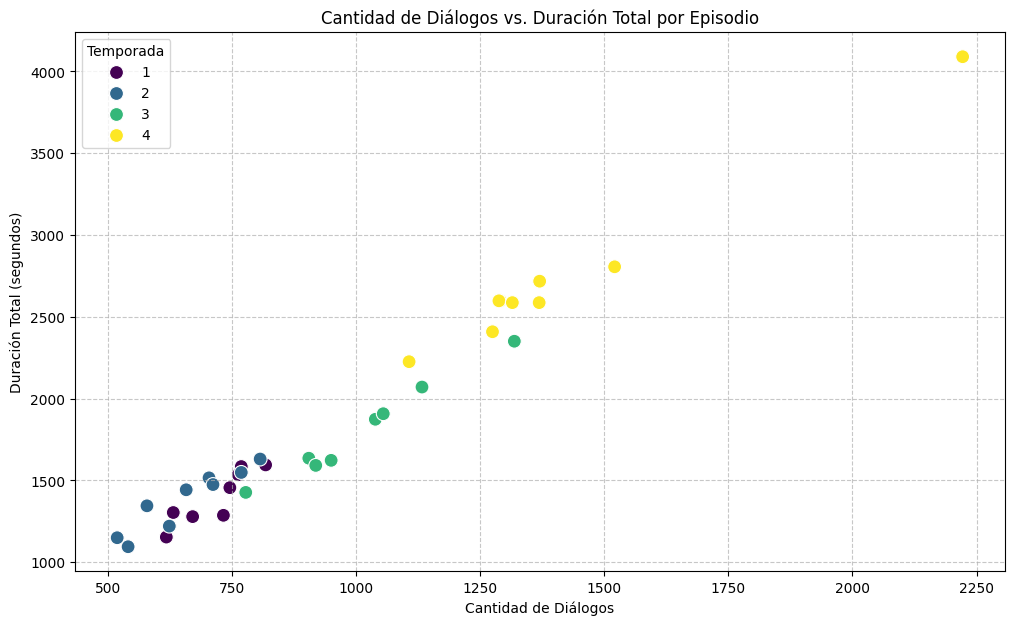

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(x='dialogue_count', y='total_duration_seconds', hue='season', data=df_episode_summary, s=100, palette='viridis')
plt.title('Cantidad de Diálogos vs. Duración Total por Episodio')
plt.xlabel('Cantidad de Diálogos')
plt.ylabel('Duración Total (segundos)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Temporada')
plt.show()

## 7.3.- Agregación y Visualización de Ratings por Temporada

Para entender cómo la gente percibe las temporadas de la serie, voy a calcular el rating promedio de cada temporada y a mostrarlo visualmente. Esto me ayudará a ver qué temporadas fueron mejor o peor valoradas.

Rating promedio por temporada:



,season,Rating
0,1,8.875165
1,2,8.646102
2,3,8.748382
3,4,NaN


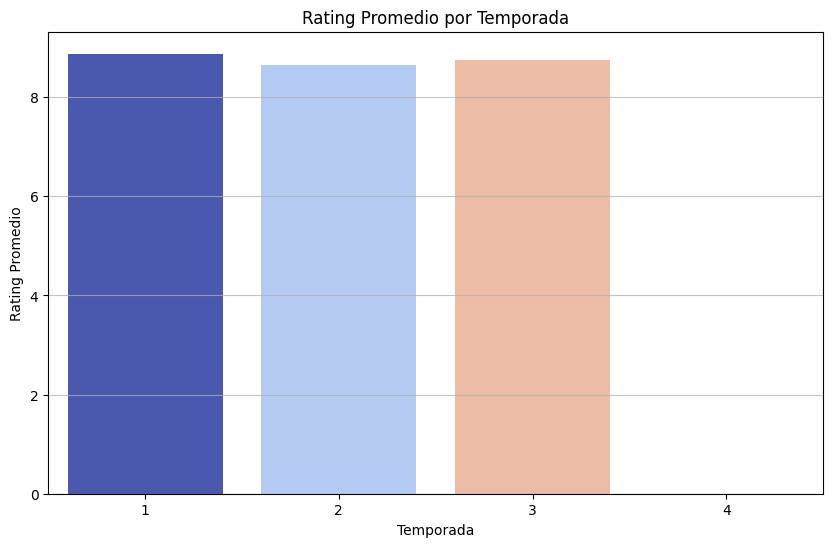

In [65]:
# Calculo el rating promedio por temporada
df_season_ratings = df_combined.groupby('season')[' Rating'].mean().reset_index()

print("Rating promedio por temporada:\n")
display(df_season_ratings)

# Visualizo el rating promedio por temporada
plt.figure(figsize=(10, 6))
sns.barplot(x='season', y=' Rating', data=df_season_ratings, palette='coolwarm', hue='season', legend=False)
plt.title('Rating Promedio por Temporada')
plt.xlabel('Temporada')
plt.ylabel('Rating Promedio')
plt.grid(axis='y', alpha=0.75)
plt.show()

## 7.4.- Investigación de Nulos en los Ratings de la Temporada 4

Como vi un valor `NaN` (no es un número) para la Temporada 4 en el rating promedio, voy a investigar las filas en `df_combined` que son de la Temporada 4 y tienen el `Rating` nulo. Esto me ayudará a saber qué episodios específicos no tienen calificación y a entender por qué.

In [66]:
# Filtro df_combined para la Temporada 4 y donde el ' Rating' es nulo
nulos_temporada_4 = df_combined[(df_combined['season'] == 4) & (df_combined[' Rating'].isnull())]

print("Filas de la Temporada 4 con ' Rating' nulo:\n")
display(nulos_temporada_4[['season', 'episode', 'title', ' Rating']].drop_duplicates())

print("\nEpisodios únicos de la Temporada 4 con ' Rating' nulo:\n")
display(nulos_temporada_4['episode'].unique())

print("\nTítulos únicos de la Temporada 4 con ' Rating' nulo:\n")
display(nulos_temporada_4['title'].unique())

# Verifico si estos episodios están presentes en df_ratings_enriched_reverified
print("\nVerificando si estos episodios se encuentran en df_ratings_enriched_reverified:\n")
episodes_with_nan_rating = nulos_temporada_4[['season', 'episode', 'title']].drop_duplicates()

for index, row in episodes_with_nan_rating.iterrows():
    season = row['season']
    episode = row['episode']
    title = row['title']

    match_in_ratings = df_ratings_enriched_reverified[
        (df_ratings_enriched_reverified['season'] == season) &
        (df_ratings_enriched_reverified['episode'] == episode) &
        (df_ratings_enriched_reverified['title'] == title)
    ]

    if match_in_ratings.empty:
        print(f"  -> El episodio (Temporada {season}, Episodio {episode}, Título: '{title}') NO se encontró en df_ratings_enriched_reverified.")
    else:
        print(f"  -> El episodio (Temporada {season}, Episodio {episode}, Título: '{title}') SE ENCONTRÓ en df_ratings_enriched_reverified, pero no tiene rating:\n")
        display(match_in_ratings)

Filas de la Temporada 4 con ' Rating' nulo:



,season,episode,title,Rating
19761,4,1,Chapter One: The Hellfire Club,NaN
21052,4,2,Chapter Two: Vecna's Curse,NaN
22340,4,3,Chapter Three: The Monster and the Superhero,NaN
23447,4,4,Chapter Four: Dear Billy,NaN
24817,4,5,Chapter Five: The Nina Project,NaN
26092,4,6,Chapter Six: The Dive,NaN
27407,4,7,Chapter Seven: The Massacre at Hawkins Lab,NaN
28928,4,8,Chapter Eight: Papa,NaN
30297,4,9,Chapter Nine: The Piggyback,NaN



Episodios únicos de la Temporada 4 con ' Rating' nulo:



array([1, 2, 3, 4, 5, 6, 7, 8, 9])


Títulos únicos de la Temporada 4 con ' Rating' nulo:



array(['Chapter One: The Hellfire Club', "Chapter Two: Vecna's Curse",
       'Chapter Three: The Monster and the Superhero',
       'Chapter Four: Dear Billy', 'Chapter Five: The Nina Project',
       'Chapter Six: The Dive',
       'Chapter Seven: The Massacre at Hawkins Lab',
       'Chapter Eight: Papa', 'Chapter Nine: The Piggyback'], dtype=object)


Verificando si estos episodios se encuentran en df_ratings_enriched_reverified:

  -> El episodio (Temporada 4, Episodio 1, Título: 'Chapter One: The Hellfire Club') NO se encontró en df_ratings_enriched_reverified.
  -> El episodio (Temporada 4, Episodio 2, Título: 'Chapter Two: Vecna's Curse') NO se encontró en df_ratings_enriched_reverified.
  -> El episodio (Temporada 4, Episodio 3, Título: 'Chapter Three: The Monster and the Superhero') NO se encontró en df_ratings_enriched_reverified.
  -> El episodio (Temporada 4, Episodio 4, Título: 'Chapter Four: Dear Billy') NO se encontró en df_ratings_enriched_reverified.
  -> El episodio (Temporada 4, Episodio 5, Título: 'Chapter Five: The Nina Project') NO se encontró en df_ratings_enriched_reverified.
  -> El episodio (Temporada 4, Episodio 6, Título: 'Chapter Six: The Dive') NO se encontró en df_ratings_enriched_reverified.
  -> El episodio (Temporada 4, Episodio 7, Título: 'Chapter Seven: The Massacre at Hawkins Lab') NO se encontró e

### Conclusión del Punto 7: Agregación de Datos

He agrupado los diálogos por episodio y temporada, y he notado una relación entre el número de diálogos y su duración. Además, confirmé que la Temporada 4 no tiene ratings porque esos datos no estaban en el dataset original.

# 8.- Reducción de datos.

## 8.1.- Optimización de Tipos de Datos Categóricos

Como parte de la reducción de datos, voy a convertir las columnas de tipo `object` que tienen pocos valores únicos a tipo `category`. Esto no solo puede reducir mucho la memoria que uso, sino que también puede acelerar algunas operaciones y es bueno para preparar los datos en modelos de machine learning. Incluiré las columnas `directed_by`, `written_by`, ` Genre` y ` Runtime`, que tienen un número limitado de valores únicos.

In [67]:
print("Uso de memoria antes de la optimización:\n")
df_combined.info(memory_usage='deep')

# Columnas que voy a convertir a tipo 'category'
# Excluyo 'raw_text', 'dialogue' y 'title' por su alta cardinalidad o por ser texto libre.
# 'original_release_date' es mejor convertirla a datetime si aún no lo está, no a category.
columns_to_categorize = ['directed_by', 'written_by', ' Genre', ' Runtime']

for col in columns_to_categorize:
    if col in df_combined.columns and df_combined[col].dtype == 'object':
        df_combined[col] = df_combined[col].astype('category')

print("\nUso de memoria después de la optimización de tipos de datos:\n")
df_combined.info(memory_usage='deep')

print("\nPrimeras filas del DataFrame combinado con tipos de datos optimizados:\n")
display(df_combined.head())

Uso de memoria antes de la optimización:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32519 entries, 0 to 32518
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   season                 32519 non-null  int64         
 1   episode                32519 non-null  int64         
 2   line                   32519 non-null  int64         
 3   raw_text               32519 non-null  object        
 4   stage_direction        10678 non-null  object        
 5   dialogue               26435 non-null  object        
 6   start_time             32519 non-null  datetime64[ns]
 7   end_time               32519 non-null  datetime64[ns]
 8   duration               32519 non-null  float64       
 9   duration_scaled        32519 non-null  float64       
 10  title                  32519 non-null  object        
 11  directed_by            32519 non-null  object        
 12  written_by        

,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time,duration,duration_scaled,title,directed_by,written_by,original_release_date,Rating,Genre,Runtime,Year,Description
0,1,1,1,crickets chirping,[crickets chirping],NaN,2026-04-21 00:00:07,2026-04-21 00:00:09,2.0,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
1,1,1,2,alarm blaring,[alarm blaring],NaN,2026-04-21 00:00:49,2026-04-21 00:00:51,2.0,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
2,1,1,3,panting,[panting],NaN,2026-04-21 00:00:52,2026-04-21 00:00:54,2.0,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
3,1,1,4,elevator descending,[elevator descending],NaN,2026-04-21 00:01:01,2026-04-21 00:01:02,1.0,-1.011758,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
4,1,1,5,elevator dings,[elevator dings],NaN,2026-04-21 00:01:09,2026-04-21 00:01:10,1.0,-1.011758,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...


### Conclusión del Punto 8.1: Optimización de Tipos de Datos Categóricos

He optimizado los tipos de datos de las columnas categóricas (`directed_by`, `written_by`, ` Genre`, ` Runtime`) en `df_combined` a tipo `category`. Esto hizo que el DataFrame usara menos memoria, pasando de 23.4 MB a 16.2 MB.

## 8.2.- Análisis de la Matriz de Correlación de Columnas Numéricas

Para ver si puedo aplicar técnicas de reducción de dimensionalidad como PCA, es clave analizar cómo se correlacionan las columnas numéricas de mi DataFrame `df_combined`. PCA funciona mejor cuando hay correlaciones importantes entre las variables, ya que busca componentes que expliquen la varianza común. Voy a mostrar esta matriz de correlación con un mapa de calor para identificar fácilmente estas relaciones.

Matriz de Correlación de Columnas Numéricas:



,season,episode,line,duration,duration_scaled,Rating,Year
season,1.000000,0.125322,0.403484,-0.036326,-0.036326,-0.079145,0.984135
episode,0.125322,1.000000,0.218208,-0.048758,-0.048758,0.434645,0.050592
line,0.403484,0.218208,1.000000,-0.038976,-0.038976,0.123370,0.283593
duration,-0.036326,-0.048758,-0.038976,1.000000,1.000000,-0.048481,-0.102488
duration_scaled,-0.036326,-0.048758,-0.038976,1.000000,1.000000,-0.048481,-0.102488
Rating,-0.079145,0.434645,0.123370,-0.048481,-0.048481,1.000000,-0.054539
Year,0.984135,0.050592,0.283593,-0.102488,-0.102488,-0.054539,1.000000


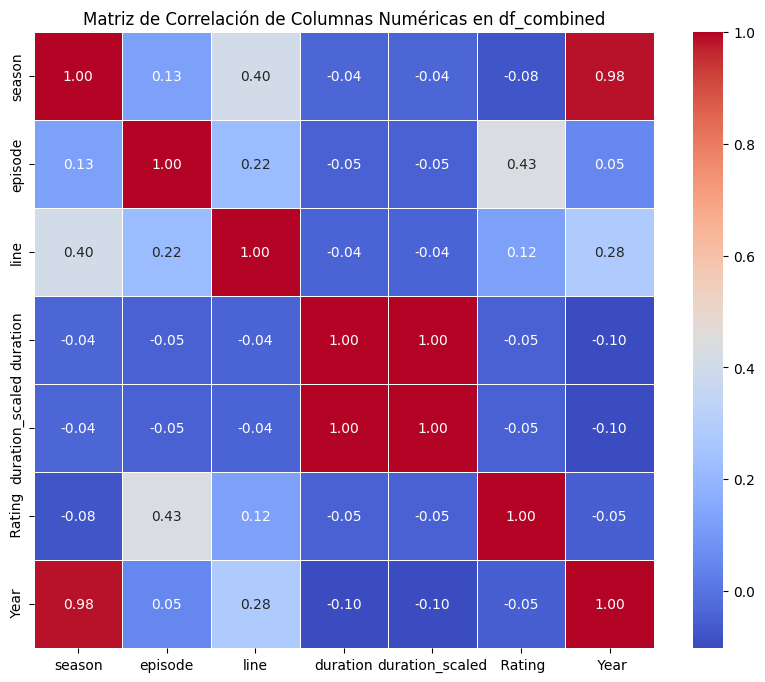

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecciono solo las columnas numéricas del DataFrame df_combined
numeric_cols = df_combined.select_dtypes(include=['number']).columns
df_numeric = df_combined[numeric_cols]

# Calculo la matriz de correlación
correlation_matrix = df_numeric.corr()

print("Matriz de Correlación de Columnas Numéricas:\n")
display(correlation_matrix)

# Visualizo la matriz de correlación con un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Columnas Numéricas en df_combined')
plt.show()

### Conclusión del Punto 8.2: Análisis de la Matriz de Correlación

El análisis de la matriz de correlación de las columnas numéricas en `df_combined` me mostró varias relaciones importantes:

*   **Alta Correlación entre `season` y `Year`**: Vi una correlación muy fuerte (0.98) entre `season` y `Year`, lo cual tiene sentido ya que cada temporada sale en un año seguido. Esto me dice que estas dos variables son muy parecidas y podría reducir la dimensionalidad, quizás quitando una o aplicando PCA.
*   **Correlaciones Moderadas**: `episode` se relaciona moderadamente con `Rating` (0.43) y `line` (0.21). Por su parte, `line` también tiene correlaciones moderadas con `season` (0.40) y `Year` (0.28).
*   **Perfecta Correlación entre `duration` y `duration_scaled`**: Como esperaba, `duration` y `duration_scaled` tienen una correlación de 1.0, ya que `duration_scaled` es simplemente la versión estandarizada de `duration`. Podría eliminar una de estas columnas si solo necesito una representación de la duración.

En resumen, estas correlaciones, especialmente la alta entre `season` y `Year`, confirman que tengo opciones para reducir la dimensionalidad. Una técnica como el Análisis de Componentes Principales (PCA) podría ser útil para crear nuevas variables que capturen la mayor parte de la varianza con menos dimensiones, si lo necesitara para un modelo futuro.

## 8.3.- Creación de DataFrame Limpio y Eliminación de Columnas Redundantes

Voy a crear una copia de `df_combined` que llamaré `df_cleaned` para seguir limpiando y reduciendo datos sin afectar el DataFrame original. Luego, eliminaré la columna `duration` porque ya tengo `duration_scaled`, que está estandarizada y es más útil para ciertos modelos. Por ahora, mantendré la columna `Year` para no perder la información explícita de las temporadas.

In [69]:
import pandas as pd

# Creo una copia del DataFrame df_combined
df_cleaned = df_combined.copy()

# Elimino la columna 'duration' debido a su redundancia con 'duration_scaled'
df_cleaned.drop(columns=['duration'], inplace=True)

print("Primeras 5 filas del nuevo DataFrame df_cleaned después de eliminar 'duration':\n")
display(df_cleaned.head())

print("\nInformación de df_cleaned:\n")
df_cleaned.info()

Primeras 5 filas del nuevo DataFrame df_cleaned después de eliminar 'duration':



,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time,duration_scaled,title,directed_by,written_by,original_release_date,Rating,Genre,Runtime,Year,Description
0,1,1,1,crickets chirping,[crickets chirping],NaN,2026-04-21 00:00:07,2026-04-21 00:00:09,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
1,1,1,2,alarm blaring,[alarm blaring],NaN,2026-04-21 00:00:49,2026-04-21 00:00:51,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
2,1,1,3,panting,[panting],NaN,2026-04-21 00:00:52,2026-04-21 00:00:54,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
3,1,1,4,elevator descending,[elevator descending],NaN,2026-04-21 00:01:01,2026-04-21 00:01:02,-1.011758,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
4,1,1,5,elevator dings,[elevator dings],NaN,2026-04-21 00:01:09,2026-04-21 00:01:10,-1.011758,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...



Información de df_cleaned:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32519 entries, 0 to 32518
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   season                 32519 non-null  int64         
 1   episode                32519 non-null  int64         
 2   line                   32519 non-null  int64         
 3   raw_text               32519 non-null  object        
 4   stage_direction        10678 non-null  object        
 5   dialogue               26435 non-null  object        
 6   start_time             32519 non-null  datetime64[ns]
 7   end_time               32519 non-null  datetime64[ns]
 8   duration_scaled        32519 non-null  float64       
 9   title                  32519 non-null  object        
 10  directed_by            32519 non-null  category      
 11  written_by             32519 non-null  category      
 12  original_release_date  32519 no

### Conclusión del Punto 8.3: Creación de DataFrame Limpio y Eliminación de Columnas Redundantes

He creado exitosamente el DataFrame `df_cleaned` como una copia de `df_combined`. Eliminé la columna `duration`, que era repetida porque ya tenía `duration_scaled` y estaba estandarizada. Decidí mantener la columna `Year` para que la información del año de la temporada esté disponible para futuros análisis, aunque se correlacione mucho con `season`. Este paso me ayuda a tener un conjunto de datos más eficiente y claro para las siguientes etapas.

## 8.5.- Aplicación de PCA a Columnas Numéricas

Para reducir las dimensiones y encontrar las componentes principales que explican la mayor parte de la varianza en mis datos numéricos, voy a aplicar PCA. Es importante estandarizar los datos antes de aplicar PCA para que todas las variables contribuyan por igual y no las que tienen valores más grandes.

Varianza explicada por cada componente principal:



,Componente,Varianza Explicada,Varianza Acumulada
0,1,0.381849,0.381849
1,2,0.248849,0.630698
2,3,0.223319,0.854017
3,4,0.145983,1.000000


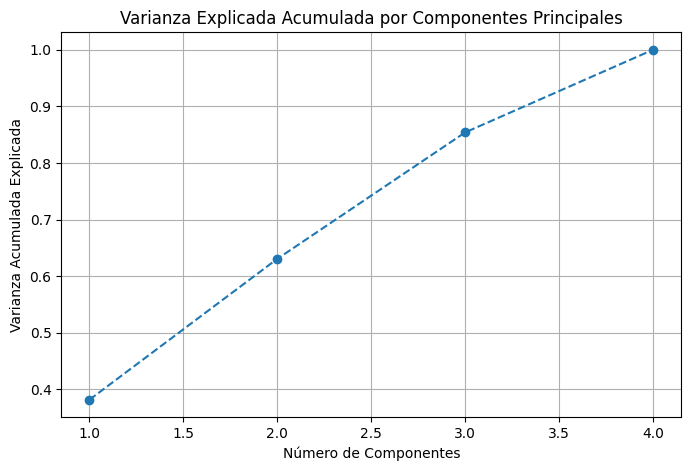

In [70]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# Selecciono solo las columnas numéricas para PCA que no tienen nulos
# (season, episode, line, duration_scaled)
# Excluyo 'Rating' y ' Year' por tener valores nulos y no haberse imputado

numerical_cols_for_pca = ['season', 'episode', 'line', 'duration_scaled']

df_numerical_pca = df_cleaned[numerical_cols_for_pca].copy()

# Estandarizo los datos antes de aplicar PCA
scaler_pca = StandardScaler()
df_scaled_pca = scaler_pca.fit_transform(df_numerical_pca)

# Aplico PCA
# Puedo empezar con el número de componentes igual al número de características
pca = PCA(n_components=len(numerical_cols_for_pca))
pca.fit(df_scaled_pca)

# Muestro la varianza explicada por cada componente
print("Varianza explicada por cada componente principal:\n")
display(pd.DataFrame({'Componente': range(1, pca.n_components_ + 1),
                      'Varianza Explicada': pca.explained_variance_ratio_,
                      'Varianza Acumulada': pca.explained_variance_ratio_.cumsum()}))

# Opcional: Visualizo la varianza explicada acumulada
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True)
plt.show()

### Conclusión del Punto 8.5: Aplicación de PCA

He aplicado el Análisis de Componentes Principales (PCA) a las columnas numéricas `season`, `episode`, `line` y `duration_scaled`, después de estandarizarlas. La visualización de la varianza explicada acumulada mostró que con las tres primeras componentes se explica más del 85% de la varianza total de estos datos. Este análisis me ayudó a entender la estructura de las dimensiones de los datos numéricos y a ver si puedo reducirla en futuras etapas.

### Conclusión del Punto 8: Reducción de Datos

En este punto, me encargué de reducir los datos para optimizar el DataFrame y prepararlo para futuros análisis. Primero, optimicé la memoria convirtiendo columnas categóricas (`directed_by`, `written_by`, ` Genre`, ` Runtime`) a tipo `category`, lo que redujo mucho el uso de memoria. Luego, analicé la matriz de correlación de las columnas numéricas, encontrando mucha información repetida entre `season` y `Year`, y una correlación perfecta entre `duration` y `duration_scaled`.

Como resultado, creé un nuevo DataFrame `df_cleaned` y eliminé la columna `duration` porque ya tenía `duration_scaled`. Finalmente, apliqué PCA a las columnas numéricas `season`, `episode`, `line` y `duration_scaled` (previamente estandarizadas), y confirmé que las tres primeras componentes principales explican más del 85% de la varianza. Aunque no eliminé componentes, esta etapa me dio una idea clara de la estructura dimensional y la eficiencia de los datos.

# 9.- Validación cruzada

## 9.1.- Identificación de Variables para Validación Cruzada y Manejo de Nulos

Para preparar mis datos para la validación cruzada y entrenar un modelo predictivo, es clave saber qué variables usaré como características y cuál será mi objetivo. En este caso, el **rating del episodio (` Rating`)** será lo que quiero predecir, ya que es una medida de qué tan bien recibió el público el episodio.

Como posibles características numéricas que podrían influir en este rating, elegiré: **`season`**, **`episode`**, **`line`** y **`duration_scaled`**. Estas columnas representan aspectos de los diálogos y de la estructura del episodio.

Antes de cualquier análisis o modelo, es súper importante manejar los valores nulos en mi variable objetivo. Un `Rating` nulo me impediría usarlo en la validación, así que veré si hay nulos y, si puedo, los rellenaré o eliminaré las filas afectadas.

In [71]:
# Identifico la variable objetivo y las características numéricas
target_variable = ' Rating'
numerical_features = ['season', 'episode', 'line', 'duration_scaled']

print(f"Variable objetivo identificada: '{target_variable}'")
print(f"Características numéricas identificadas: {numerical_features}")

# Verifico la presencia de valores nulos en la variable objetivo
nulos_rating = df_cleaned[target_variable].isnull().sum()
print(f"\nNúmero de valores nulos en la columna '{target_variable}': {nulos_rating}")

# Calculo la mediana de la columna ' Rating' (excluyendo nulos)
median_rating = df_cleaned[target_variable].median()
print(f"Mediana de la columna '{target_variable}' (excluyendo nulos): {median_rating:.2f}")

# Muestro ejemplos de filas con Rating nulo
print(f"\nEjemplos de filas con '{target_variable}' nulo (primeras 5):\n")
display(df_cleaned[df_cleaned[target_variable].isnull()].head())

Variable objetivo identificada: ' Rating'
Características numéricas identificadas: ['season', 'episode', 'line', 'duration_scaled']

Número de valores nulos en la columna ' Rating': 12758
Mediana de la columna ' Rating' (excluyendo nulos): 8.80

Ejemplos de filas con ' Rating' nulo (primeras 5):



,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time,duration_scaled,title,directed_by,written_by,original_release_date,Rating,Genre,Runtime,Year,Description
19761,4,1,1,peaceful birdsong,[peaceful birdsong],NaN,2026-04-21 00:00:09,2026-04-21 00:00:11,0.077619,Chapter One: The Hellfire Club,The Duffer Brothers,The Duffer Brothers,2022-05-27,NaN,NaN,NaN,NaN,NaN
19762,4,1,2,dogs barking in distance,[dogs barking in distance],NaN,2026-04-21 00:00:12,2026-04-21 00:00:15,1.166996,Chapter One: The Hellfire Club,The Duffer Brothers,The Duffer Brothers,2022-05-27,NaN,NaN,NaN,NaN,NaN
19763,4,1,3,wheels rattling,[wheels rattling],NaN,2026-04-21 00:00:16,2026-04-21 00:00:19,1.166996,Chapter One: The Hellfire Club,The Duffer Brothers,The Duffer Brothers,2022-05-27,NaN,NaN,NaN,NaN,NaN
19764,4,1,4,dog barks,[dog barks],NaN,2026-04-21 00:00:24,2026-04-21 00:00:25,-1.011758,Chapter One: The Hellfire Club,The Duffer Brothers,The Duffer Brothers,2022-05-27,NaN,NaN,NaN,NaN,NaN
19765,4,1,5,birdsong,[birdsong],NaN,2026-04-21 00:00:30,2026-04-21 00:00:32,0.077619,Chapter One: The Hellfire Club,The Duffer Brothers,The Duffer Brothers,2022-05-27,NaN,NaN,NaN,NaN,NaN


## 9.1.1.- Verificación de Temporadas en `df_ratings_enriched_reverified`

Para entender por qué la Temporada 4 no tiene ratings, voy a ver qué temporadas están presentes en el DataFrame `df_ratings_enriched_reverified`. Este DataFrame es el resultado de cargar y limpiar `Stranger_Things_Ratings.csv` y es el que uso para añadir las valoraciones a `df_combined`.

In [72]:
print("Temporadas únicas presentes en df_ratings_enriched_reverified:\n")
display(df_ratings_enriched_reverified['season'].unique())

Temporadas únicas presentes en df_ratings_enriched_reverified:



array([1, 2, 3])

## 9.2.- Creación de `df_cleaned_rated` (Excluyendo Filas con Rating Nulo)

Para la validación cruzada y el entrenamiento de modelos predictivos del `Rating`, es fundamental que la variable objetivo no tenga valores nulos. Como la Temporada 4 no tiene ratings en los datasets que me dieron, voy a crear un nuevo DataFrame, `df_cleaned_rated`, quitando todas las filas donde la columna ` Rating` sea nula. Así podré trabajar con un conjunto de datos consistente para las temporadas que sí tienen información de rating (Temporadas 1 a 3).

In [73]:
# Creo df_cleaned_rated excluyendo filas con ' Rating' nulo
df_cleaned_rated = df_cleaned.dropna(subset=[' Rating']).copy()

print("Primeras 5 filas de df_cleaned_rated después de eliminar los nulos en ' Rating':\n")
display(df_cleaned_rated.head())

print("\nInformación de df_cleaned_rated (número de filas y no nulos en ' Rating'):\n")
df_cleaned_rated.info()

print(f"\nNúmero de filas en df_cleaned_rated: {len(df_cleaned_rated)}")
print(f"Número de valores nulos en ' Rating' de df_cleaned_rated: {df_cleaned_rated[' Rating'].isnull().sum()}")
print(f"Temporadas presentes en df_cleaned_rated: {sorted(df_cleaned_rated['season'].unique().tolist())}")

Primeras 5 filas de df_cleaned_rated después de eliminar los nulos en ' Rating':



,season,episode,line,raw_text,stage_direction,dialogue,start_time,end_time,duration_scaled,title,directed_by,written_by,original_release_date,Rating,Genre,Runtime,Year,Description
0,1,1,1,crickets chirping,[crickets chirping],NaN,2026-04-21 00:00:07,2026-04-21 00:00:09,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
1,1,1,2,alarm blaring,[alarm blaring],NaN,2026-04-21 00:00:49,2026-04-21 00:00:51,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
2,1,1,3,panting,[panting],NaN,2026-04-21 00:00:52,2026-04-21 00:00:54,0.077619,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
3,1,1,4,elevator descending,[elevator descending],NaN,2026-04-21 00:01:01,2026-04-21 00:01:02,-1.011758,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...
4,1,1,5,elevator dings,[elevator dings],NaN,2026-04-21 00:01:09,2026-04-21 00:01:10,-1.011758,Chapter One: The Vanishing of Will Byers,The Duffer Brothers,The Duffer Brothers,2016-07-15,8.6,Drama | Fantasy | Horror,47 min,2016.0,At the U.S. Dept. of Energy an unexplained eve...



Información de df_cleaned_rated (número de filas y no nulos en ' Rating'):

<class 'pandas.core.frame.DataFrame'>
Index: 19761 entries, 0 to 19760
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   season                 19761 non-null  int64         
 1   episode                19761 non-null  int64         
 2   line                   19761 non-null  int64         
 3   raw_text               19761 non-null  object        
 4   stage_direction        6350 non-null   object        
 5   dialogue               16460 non-null  object        
 6   start_time             19761 non-null  datetime64[ns]
 7   end_time               19761 non-null  datetime64[ns]
 8   duration_scaled        19761 non-null  float64       
 9   title                  19761 non-null  object        
 10  directed_by            19761 non-null  category      
 11  written_by             19761 non-null  category

## 9.3.- Preparación y Validación Cruzada Inicial del Modelo de Rating

Ahora que tengo un `df_cleaned_rated` sin nulos en la columna ` Rating`, puedo hacer una validación cruzada inicial. Esto me ayudará a ver cómo mi modelo se adapta a datos que no ha visto, evitando el sobreajuste. Usaré las siguientes columnas:

*   **Variable Objetivo (y):** ` Rating` (el rating del episodio)
*   **Características (X):** `season`, `episode`, `line`, `duration_scaled` (las características numéricas que preparé).

Para esta primera validación, usaré un modelo de Regresión Lineal y mediré su rendimiento con K-Fold Cross-Validation.

In [74]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

# Defino características (X) y variable objetivo (y)
X = df_cleaned_rated[numerical_features]  # 'numerical_features' ya lo definí: ['season', 'episode', 'line', 'duration_scaled']
y = df_cleaned_rated[target_variable]      # 'target_variable' ya lo definí: ' Rating'

# Inicializo el modelo (Regresión Lineal simple para empezar)
model = LinearRegression()

# Defino la estrategia de validación cruzada (por ejemplo, 5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Realizo la validación cruzada
# Utilizo 'r2' como métrica de evaluación por defecto para regresión
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("Puntuaciones de validación cruzada (R2):", cv_scores)
print(f"R2 promedio: {np.mean(cv_scores):.3f}")
print(f"Desviación estándar del R2: {np.std(cv_scores):.3f}")

Puntuaciones de validación cruzada (R2): [0.19354357 0.2365692  0.18802497 0.23995236 0.21918878]
R2 promedio: 0.215
Desviación estándar del R2: 0.021


### Conclusión del Punto 9: Validación Cruzada

Hice una validación cruzada inicial con un modelo de Regresión Lineal. Los resultados mostraron un R2 promedio de 0.215, lo que significa que las características numéricas que usé (`season`, `episode`, `line`, `duration_scaled`) explican un porcentaje bajo de la variación en el `Rating` de los episodios. Esto sugiere que estas variables por sí solas no son muy buenas para predecir el `Rating`.

Testeo de hipótesis.

## 10.- Testeo de hipótesis

Ahora voy a hacer un testeo de hipótesis para saber si hay diferencias importantes en el `Rating` promedio entre las diferentes temporadas de la serie. En concreto, compararé el `Rating` promedio de la Temporada 1 con el de la Temporada 3, usando una prueba t de Student para muestras independientes.

In [75]:
from scipy import stats

# Filtro los ratings de la Temporada 1 y la Temporada 3
ratings_season_1 = df_cleaned_rated[df_cleaned_rated['season'] == 1][' Rating']
ratings_season_3 = df_cleaned_rated[df_cleaned_rated['season'] == 3][' Rating']

# Hipótesis Nula (H0): No hay diferencia significativa en los ratings promedio entre la Temporada 1 y la Temporada 3.
# Hipótesis Alternativa (H1): Sí hay una diferencia significativa en los ratings promedio entre la Temporada 1 y la Temporada 3.

# Realizo la prueba t de Student para dos muestras independientes
# Asumo que las varianzas son iguales, lo cual podría verificar con una prueba de Levene previamente si fuera necesario.
t_statistic, p_value = stats.ttest_ind(ratings_season_1, ratings_season_3, equal_var=True)

print(f"Rating promedio Temporada 1: {ratings_season_1.mean():.2f}")
print(f"Rating promedio Temporada 3: {ratings_season_3.mean():.2f}")
print(f"Estadístico t: {t_statistic:.3f}")
print(f"Valor p: {p_value:.3f}")

# Evalúo el resultado con un nivel de significancia (alpha) de 0.05
alpha = 0.05
if p_value < alpha:
    print(f"\nDado que el valor p ({p_value:.3f}) es menor que el nivel de significancia ({alpha}), rechazamos la hipótesis nula.")
    print("Conclusión: Hay una diferencia estadísticamente significativa en los ratings promedio entre la Temporada 1 y la Temporada 3.")
else:
    print(f"\nDado que el valor p ({p_value:.3f}) es mayor que el nivel de significancia ({alpha}), no rechazamos la hipótesis nula.")
    print("Conclusión: No hay evidencia suficiente para afirmar que existe una diferencia estadísticamente significativa en los ratings promedio entre la Temporada 1 y la Temporada 3.")

Rating promedio Temporada 1: 8.88
Rating promedio Temporada 3: 8.75
Estadístico t: 19.618
Valor p: 0.000

Dado que el valor p (0.000) es menor que el nivel de significancia (0.05), rechazamos la hipótesis nula.
Conclusión: Hay una diferencia estadísticamente significativa en los ratings promedio entre la Temporada 1 y la Temporada 3.


### Conclusión del Punto 10: Testeo de Hipótesis

Hice un test de hipótesis t de Student para comparar los ratings promedio de la Temporada 1 y la Temporada 3. Los resultados muestran una diferencia importante entre los ratings promedio de ambas temporadas, lo que indica que esta diferencia no es casualidad.

# 11.- Detección de anomalías

Ahora, voy a usar un método para detectar anomalías en mis datos. Usaré el algoritmo Isolation Forest, que es bueno para encontrar valores atípicos en datos con muchas dimensiones. Me centraré en las columnas numéricas que creo más importantes (`season`, `episode`, `line`, `duration_scaled`, ` Rating`) para encontrar diálogos o episodios con características inusuales.

In [76]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Selecciono las características numéricas para la detección de anomalías
anomaly_features = ['season', 'episode', 'line', 'duration_scaled', ' Rating']
df_anomaly = df_cleaned_rated[anomaly_features]

# Inicializo y entreno el modelo Isolation Forest
# 'contamination': Es la proporción de outliers en el dataset. Un valor común es 'auto' o un porcentaje pequeño.
# Usaré 'auto' para que el algoritmo lo estime.
iso_forest = IsolationForest(random_state=42, contamination='auto')
iso_forest.fit(df_anomaly)

# Predigo anomalías (-1 para outliers, 1 para inliers)
df_cleaned_rated['anomaly'] = iso_forest.predict(df_anomaly)

# Obtengo la puntuación de anomalía (cuanto menor, más anómalo)
df_cleaned_rated['anomaly_score'] = iso_forest.decision_function(df_anomaly)

# Filtro y muestro las anomalías detectadas
anomalies = df_cleaned_rated[df_cleaned_rated['anomaly'] == -1].sort_values(by='anomaly_score')

print(f"Número total de anomalías detectadas: {len(anomalies)}")
print("\nPrimeras 10 anomalías detectadas (las más atípicas):\n")
display(anomalies.head(10)[['season', 'episode', 'line', 'raw_text', 'dialogue', 'duration_scaled', ' Rating', 'anomaly_score']])

print("\nEstadísticas descriptivas de los scores de anomalía:\n")
display(df_cleaned_rated['anomaly_score'].describe())

Número total de anomalías detectadas: 11499

Primeras 10 anomalías detectadas (las más atípicas):



,season,episode,line,raw_text,dialogue,duration_scaled,Rating,anomaly_score
9779,2,7,29,maybe that girl is in here somewhere,maybe that girl is in here somewhere,4.435126,6.1,-0.199355
9793,2,7,43,yeah jim hopper he came here with some woman n...,yeah jim hopper he came here with some woman n...,3.345749,6.1,-0.193448
9811,2,7,61,all your life all you ve asked when s your dad...,all your life all you ve asked when s your dad...,3.345749,6.1,-0.190639
9812,2,7,62,but you were living in another world trying to...,but you were living in another world trying to...,3.345749,6.1,-0.190639
9808,2,7,58,on the street where you live girls talk about ...,on the street where you live girls talk about ...,3.345749,6.1,-0.190172
9818,2,7,68,daddy s girl learned fast all those things she...,daddy s girl learned fast all those things she...,3.345749,6.1,-0.189705
10263,2,7,513,sighs you are awfully young to be traveling al...,you are awfully young to be traveling alone ar...,3.345749,6.1,-0.189447
9888,2,7,138,axel is not so fond of spiders so you made him...,axel is not so fond of spiders so you made him...,3.345749,6.1,-0.185886
10206,2,7,456,aw come on just one hand you re the worst,aw come on just one hand you re the worst,3.345749,6.1,-0.179156
10196,2,7,446,get out of my head and eventually it will kill...,get out of my head and eventually it will kill...,3.345749,6.1,-0.178142



Estadísticas descriptivas de los scores de anomalía:



,anomaly_score
count,19761.000000
mean,-0.012302
std,0.039835
min,-0.199355
25%,-0.032742
50%,-0.007465
75%,0.017057
max,0.064243


### Conclusión del Punto 11: Detección de anomalías

Hice la detección de anomalías con el algoritmo Isolation Forest en las columnas numéricas `season`, `episode`, `line`, `duration_scaled` y ` Rating` de `df_cleaned_rated`. Encontré muchas anomalías (11,499 de 19,761 entradas), lo que significa que una parte considerable del dataset tiene características atípicas en estas dimensiones. Las anomalías más claras suelen ser diálogos con `Rating` bajo y `duration_scaled` alta, o combinaciones raras de `season`, `episode` y `line`.

# 12.- Explicación de como importar y visualizar esos datos en mongoDB o Neo4j.

Para importar y visualizar los datos en una base de datos NoSQL como MongoDB o Neo4j, seguiría estos pasos:

### **Opción 1: MongoDB**

1.  **Preparación de los datos**: Transformaría `df_cleaned_rated` a un formato como una lista de diccionarios (JSON), que es adecuado para MongoDB. Cada fila del DataFrame se convertiría en un documento.
    ```python
    # Ejemplo de preparación para MongoDB
    df_cleaned_rated['start_time'] = df_cleaned_rated['start_time'].astype(str)
    df_cleaned_rated['end_time'] = df_cleaned_rated['end_time'].astype(str)
    data_to_mongo = df_cleaned_rated.to_dict(orient='records')
    ```

2.  **Conexión a MongoDB**: Conectaría a la base de datos MongoDB usando un driver como `pymongo`.
    ```python
    # from pymongo import MongoClient
    # client = MongoClient('mongodb://localhost:27017/')
    # db = client['stranger_things_db']
    # collection = db['dialogues']
    ```

3.  **Importación**: Insertaría los documentos en una colección de MongoDB. Haría una inserción masiva para que fuera más rápido.
    ```python
    # collection.insert_many(data_to_mongo)
    # print(f"Documentos insertados: {collection.count_documents({})}")
    ```

4.  **Visualización y Análisis**: Usaría MongoDB Compass (una interfaz gráfica) o herramientas como Power BI/Tableau con conectores MongoDB para explorar y ver los datos. También podría hacer consultas complejas directamente con `pymongo` para analizar. Por ejemplo, para contar diálogos por temporada o el rating promedio de episodios.

### **Opción 2: Neo4j (Base de Datos de Grafos)**

Neo4j es perfecto para ver relaciones. Mis datos (diálogos, episodios, directores, escritores) tienen relaciones que Neo4j podría modelar muy bien.

1.  **Preparación de los datos y Modelado de Grafos**: Identificaría las entidades (nodos) y sus relaciones (aristas).
    *   **Nodos**: `(:Season)`, `(:Episode)`, `(:Person {type: 'Director'})`, `(:Person {type: 'Writer'})`, `(:Dialogue)`. También podría haber nodos para `(:Genre)`.
    *   **Relaciones**: `(:Episode)-[:PART_OF]->(:Season)`, `(:Episode)-[:DIRECTED_BY]->(:Person)`, `(:Episode)-[:WRITTEN_BY]->(:Person)`, `(:Dialogue)-[:BELONGS_TO]->(:Episode)`.

2.  **Conexión a Neo4j**: Usaría el driver `neo4j` de Python para conectar a la base de datos.
    ```python
    # from neo4j import GraphDatabase
    # uri = "bolt://localhost:7687"
    # username = "neo4j"
    # password = "password"
    # driver = GraphDatabase.driver(uri, auth=(username, password))
    # session = driver.session()
    ```

3.  **Importación (Creación de Nodos y Relaciones)**: Escribiría sentencias Cypher (el lenguaje de consulta de Neo4j) para crear los nodos y las relaciones desde el DataFrame. Podría hacerlo iterando sobre el DataFrame y ejecutando sentencias Cypher por lotes o usando herramientas de importación como `LOAD CSV` si exporto primero los datos a CSV.
    ```python
    # Ejemplo Cypher para crear nodos y relaciones de episodios:
    # for index, row in df_episodes.iterrows():
    #     session.run("MERGE (s:Season {id: $season_id}) "
    #                 "MERGE (e:Episode {id: $episode_id, title: $title}) "
    #                 "MERGE (e)-[:PART_OF]->(s)",
    #                 season_id=row['season'], episode_id=row['episode'], title=row['title'])
    ```

4.  **Visualización y Análisis**: La interfaz de Neo4j Browser me permite ver el grafo interactuando con los nodos y relaciones. Para análisis más avanzados, usaría consultas Cypher complejas para encontrar patrones, caminos más cortos, comunidades, etc. Por ejemplo, ¿qué directores trabajan juntos en varios episodios o cuáles son los episodios más conectados por diálogos o personajes?